# Weekly Context-Aware LSTM Classifier Training

This notebook trains weekly LSTM classifiers for next-week stock direction using technical features, VIX/VXN volatility-context features, HMM next-step probabilities, and combined information sets.

Research question: does adding external volatility context from VIX and VXN improve next-week stock-direction classification beyond technical features and HMM regime probabilities?

Important guardrails:

- Target remains `Target_State_Binary`: 1 = next-week return > 0, 0 = next-week return <= 0.
- No regression target is created.
- No daily data is used.
- The HMM is not refitted here; only saved next-step HMM probability features are loaded.

## 1. Imports and configuration

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.utils.class_weight import compute_class_weight

from weekly_lstm_architecture import (
    WeeklyLSTMConfig,
    build_weekly_lstm_classifier,
    get_weekly_callbacks,
    set_global_seed,
)

plt.style.use("default")
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)

SEED = 42
set_global_seed(SEED)

In [2]:
PROJECT_ROOT = Path.cwd()

CONTEXT_INPUT_PATH = PROJECT_ROOT / "outputs" / "weekly_context" / "model_df_weekly_with_vol_context_scaled.parquet"
HMM_FEATURE_SOURCE_PATH = PROJECT_ROOT / "outputs" / "weekly_hmm" / "weekly_hmm_regime_features.parquet"

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "weekly_context_lstm"
PLOTS_DIR = OUTPUT_DIR / "plots"
MODEL_DIR = PROJECT_ROOT / "models" / "weekly_context_lstm"

for directory in [OUTPUT_DIR, PLOTS_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

TICKERS = ["AAPL", "IBM", "MSFT"]
LOOKBACK_GRID = [4, 8, 12, 26]
RUN_FULL_GRID = True

TARGET_COL = "Target_State_Binary"
MERGE_KEYS = ["Ticker", "Date", "Target_Date", "Split"]

MAX_EPOCHS = 80
PATIENCE = 12
BATCH_SIZE = 16
THRESHOLDS = np.round(np.arange(0.05, 0.951, 0.01), 2)
LOW_PROBABILITY_STD_CUTOFF = 0.02

print(f"Project root: {PROJECT_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Run full grid: {RUN_FULL_GRID}")

Project root: d:\BA_year_3\honour project
Output directory: d:\BA_year_3\honour project\outputs\weekly_context_lstm
Run full grid: True


## 2. Feature sets and leakage checks

In [3]:
BASELINE_WEEKLY_FEATURES = [
    "Weekly_Log_Return",
    "Weekly_Open_Close_Log_Return",
    "Weekly_High_Low_Range",
    "Weekly_Volume_Change",
    "Rolling_Vol_4",
    "Rolling_Vol_12",
    "Rolling_Vol_26",
    "Momentum_4",
    "Momentum_12",
    "Momentum_26",
    "MA_Gap_4",
    "MA_Gap_12",
    "MA_Gap_26",
    "Drawdown_12",
    "Drawdown_26",
]

VOL_CONTEXT_FEATURES_FULL = [
    "VIX_Close",
    "VIX_Change",
    "VIX_Log_Change",
    "VIX_MA_4",
    "VIX_MA_12",
    "VIX_ZScore_12",
    "VIX_Above_MA_12",
    "VXN_Close",
    "VXN_Change",
    "VXN_Log_Change",
    "VXN_MA_4",
    "VXN_MA_12",
    "VXN_ZScore_12",
    "VXN_Above_MA_12",
    "VXN_minus_VIX",
    "VXN_to_VIX",
]

VOL_CONTEXT_FEATURES_COMPACT = [
    "VIX_Close",
    "VIX_Log_Change",
    "VIX_ZScore_12",
    "VIX_Above_MA_12",
    "VXN_Close",
    "VXN_Log_Change",
    "VXN_ZScore_12",
    "VXN_Above_MA_12",
    "VXN_minus_VIX",
    "VXN_to_VIX",
]

HMM_FEATURES = [
    "HMM_Bullish_Prob_Next",
    "HMM_Positive_Return_Prob_Next",
]

FEATURE_CONFIGS = {
    "technical_only": BASELINE_WEEKLY_FEATURES,
    "vol_context_compact": BASELINE_WEEKLY_FEATURES + VOL_CONTEXT_FEATURES_COMPACT,
    "vol_context_full": BASELINE_WEEKLY_FEATURES + VOL_CONTEXT_FEATURES_FULL,
    "hmm_informed": BASELINE_WEEKLY_FEATURES + HMM_FEATURES,
    "vol_context_compact_hmm": BASELINE_WEEKLY_FEATURES + VOL_CONTEXT_FEATURES_COMPACT + HMM_FEATURES,
    "vol_context_full_hmm": BASELINE_WEEKLY_FEATURES + VOL_CONTEXT_FEATURES_FULL + HMM_FEATURES,
}

EXPECTED_FEATURE_COUNTS = {
    "technical_only": 15,
    "vol_context_compact": 25,
    "vol_context_full": 31,
    "hmm_informed": 17,
    "vol_context_compact_hmm": 27,
    "vol_context_full_hmm": 33,
}

if not RUN_FULL_GRID:
    FEATURE_CONFIGS = {
        key: FEATURE_CONFIGS[key]
        for key in ["technical_only", "vol_context_compact", "hmm_informed", "vol_context_compact_hmm"]
    }

LEAKAGE_COLUMNS = {
    "Ticker",
    "Date",
    "Target_Date",
    "Split",
    "Target_State_Binary",
    "Target_State",
    "Next_Week_Log_Return",
    "HMM_State",
    "HMM_Regime_Label",
}

for config_name, feature_cols in FEATURE_CONFIGS.items():
    duplicate_features = pd.Series(feature_cols)[pd.Series(feature_cols).duplicated()].tolist()
    if duplicate_features:
        raise ValueError(f"{config_name} has duplicate features: {duplicate_features}")
    leakage_used = sorted(set(feature_cols).intersection(LEAKAGE_COLUMNS))
    if leakage_used:
        raise ValueError(f"{config_name} uses leakage columns: {leakage_used}")
    expected_count = EXPECTED_FEATURE_COUNTS[config_name]
    if len(feature_cols) != expected_count:
        raise ValueError(f"{config_name} expected {expected_count} features, found {len(feature_cols)}")

if any("smooth" in col.lower() for cols in FEATURE_CONFIGS.values() for col in cols):
    raise ValueError("Smoothed HMM probabilities are not allowed in this experiment.")
if any(col.startswith("HMM_") and col not in HMM_FEATURES for cols in FEATURE_CONFIGS.values() for col in cols):
    raise ValueError("Only the requested next-step HMM probability features may be used.")

HMM_REFITTED_IN_THIS_NOTEBOOK = False
EXPECTED_TRAINING_RUNS = len(TICKERS) * len(LOOKBACK_GRID) * len(FEATURE_CONFIGS)

feature_count_df = pd.DataFrame(
    [{"feature_config": name, "feature_count": len(cols)} for name, cols in FEATURE_CONFIGS.items()]
)
display(feature_count_df)
print(f"Expected training runs: {EXPECTED_TRAINING_RUNS}")

,feature_config,feature_count
0,technical_only,15
1,vol_context_compact,25
2,vol_context_full,31
3,hmm_informed,17
4,vol_context_compact_hmm,27
5,vol_context_full_hmm,33


Expected training runs: 72


## 3. Load scaled context data and saved HMM features

In [4]:
def require_columns(df: pd.DataFrame, required_cols: list[str], name: str) -> None:
    missing = [col for col in required_cols if col not in df.columns]
    if missing:
        raise ValueError(f"{name} is missing required columns: {missing}")


required_context_cols = sorted(set(MERGE_KEYS + [TARGET_COL, "Target_State", "Next_Week_Log_Return"] + [col for cols in FEATURE_CONFIGS.values() for col in cols if col not in HMM_FEATURES]))
required_hmm_cols = MERGE_KEYS + HMM_FEATURES

context_df = pd.read_parquet(CONTEXT_INPUT_PATH)
hmm_feature_df = pd.read_parquet(HMM_FEATURE_SOURCE_PATH)

for df in [context_df, hmm_feature_df]:
    df["Date"] = pd.to_datetime(df["Date"])
    df["Target_Date"] = pd.to_datetime(df["Target_Date"])

require_columns(context_df, required_context_cols, "scaled context dataset")
require_columns(hmm_feature_df, required_hmm_cols, "weekly HMM regime features")

original_row_count = len(context_df)
model_df = context_df.merge(
    hmm_feature_df[required_hmm_cols],
    on=MERGE_KEYS,
    how="left",
    validate="one_to_one",
)

if len(model_df) != original_row_count:
    raise ValueError(f"HMM merge changed row count: {original_row_count} -> {len(model_df)}")

all_feature_cols = sorted(set(col for cols in FEATURE_CONFIGS.values() for col in cols))
missing_values = model_df[all_feature_cols + [TARGET_COL]].isna().sum()
if missing_values.sum() > 0:
    raise ValueError(f"Missing values found after merge:\n{missing_values[missing_values > 0]}")

for col in HMM_FEATURES:
    if not model_df[col].between(0, 1).all():
        raise ValueError(f"{col} must be bounded between 0 and 1.")

model_df = model_df.sort_values(["Ticker", "Date"]).reset_index(drop=True)

print(f"Context rows before merge: {original_row_count}")
print(f"Rows after HMM merge: {len(model_df)}")
print("HMM was not refitted; saved next-step HMM probabilities were merged only.")
display(model_df[MERGE_KEYS + HMM_FEATURES].head())

Context rows before merge: 2391
Rows after HMM merge: 2391
HMM was not refitted; saved next-step HMM probabilities were merged only.


,Ticker,Date,Target_Date,Split,HMM_Bullish_Prob_Next,HMM_Positive_Return_Prob_Next
0,AAPL,2010-09-24,2010-10-01,train,0.461624,0.557774
1,AAPL,2010-10-01,2010-10-08,train,0.342137,0.531155
2,AAPL,2010-10-08,2010-10-15,train,0.447052,0.554528
3,AAPL,2010-10-15,2010-10-22,train,0.305537,0.523002
4,AAPL,2010-10-22,2010-10-29,train,0.323117,0.526918


## 4. Sequence creation

In [5]:
def create_lstm_sequences_for_ticker(
    df_ticker: pd.DataFrame,
    feature_cols: list[str],
    lookback: int,
    target_col: str = TARGET_COL,
) -> tuple[dict[str, np.ndarray], pd.DataFrame]:
    if lookback < 1:
        raise ValueError("lookback must be at least 1")

    df_ticker = df_ticker.sort_values("Date").reset_index(drop=True)
    feature_matrix = df_ticker[feature_cols].to_numpy(dtype=np.float32)
    target_values = df_ticker[target_col].to_numpy(dtype=np.int64)
    split_values = df_ticker["Split"].astype(str).to_numpy()

    X_by_split = {"train": [], "validation": [], "test": []}
    y_by_split = {"train": [], "validation": [], "test": []}
    sequence_info_rows = []

    for i in range(lookback - 1, len(df_ticker)):
        target_split = split_values[i]
        if target_split not in X_by_split:
            raise ValueError(f"Unexpected split value: {target_split}")

        X_by_split[target_split].append(feature_matrix[i - lookback + 1 : i + 1])
        y_by_split[target_split].append(target_values[i])
        sequence_info_rows.append(
            {
                "Ticker": df_ticker.loc[i, "Ticker"],
                "Date": df_ticker.loc[i, "Date"],
                "Target_Date": df_ticker.loc[i, "Target_Date"],
                "Split": target_split,
                "Target_State_Binary": int(target_values[i]),
            }
        )

    def stack_X(split: str) -> np.ndarray:
        values = X_by_split[split]
        if not values:
            return np.empty((0, lookback, len(feature_cols)), dtype=np.float32)
        return np.stack(values).astype(np.float32)

    arrays = {}
    for split in ["train", "validation", "test"]:
        arrays[f"X_{split}"] = stack_X(split)
        arrays[f"y_{split}"] = np.asarray(y_by_split[split], dtype=np.int64)

    return arrays, pd.DataFrame(sequence_info_rows)


def get_ticker_frame(ticker: str) -> pd.DataFrame:
    df_ticker = model_df.loc[model_df["Ticker"] == ticker].copy()
    if df_ticker.empty:
        raise ValueError(f"No rows found for ticker {ticker}")
    return df_ticker.sort_values("Date").reset_index(drop=True)

## 5. Training and evaluation helpers

In [6]:
def select_validation_threshold(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    thresholds: np.ndarray = THRESHOLDS,
) -> tuple[float, float, pd.DataFrame]:
    y_true = np.asarray(y_true).reshape(-1).astype(int)
    y_prob = np.asarray(y_prob).reshape(-1).astype(float)
    if len(y_true) == 0:
        raise ValueError("Cannot select a threshold with an empty validation set.")

    records = []
    for threshold in thresholds:
        y_pred = (y_prob >= threshold).astype(int)
        records.append(
            {
                "threshold": float(threshold),
                "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
                "accuracy": accuracy_score(y_true, y_pred),
                "f1": f1_score(y_true, y_pred, zero_division=0),
                "predicted_bullish_share": float(np.mean(y_pred)),
                "distance_from_0_5": abs(float(threshold) - 0.5),
            }
        )

    threshold_df = pd.DataFrame(records)
    best_row = threshold_df.sort_values(
        ["balanced_accuracy", "distance_from_0_5", "threshold"],
        ascending=[False, True, True],
    ).iloc[0]
    return (
        float(best_row["threshold"]),
        float(best_row["balanced_accuracy"]),
        threshold_df.drop(columns=["distance_from_0_5"]),
    )


def evaluate_probabilities(y_true: np.ndarray, y_prob: np.ndarray, threshold: float) -> dict[str, float]:
    y_true = np.asarray(y_true).reshape(-1).astype(int)
    y_prob = np.asarray(y_prob).reshape(-1).astype(float)
    if len(y_true) == 0:
        raise ValueError("Cannot evaluate an empty target array.")
    if len(y_true) != len(y_prob):
        raise ValueError(f"y_true and y_prob length mismatch: {len(y_true)} != {len(y_prob)}")

    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    prob_std = float(np.std(y_prob))
    predicted_bullish_share = float(np.mean(y_pred))

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "kappa": cohen_kappa_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else np.nan,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "share_predicted_bullish": predicted_bullish_share,
        "share_actual_bullish": float(np.mean(y_true)),
        "probability_mean": float(np.mean(y_prob)),
        "probability_std": prob_std,
        "probability_min": float(np.min(y_prob)),
        "probability_max": float(np.max(y_prob)),
        "degenerate_prediction_warning": predicted_bullish_share <= 0.05 or predicted_bullish_share >= 0.95,
        "low_probability_variation_warning": prob_std < LOW_PROBABILITY_STD_CUTOFF,
    }


def add_prefixed_metrics(row: dict, prefix: str, metrics: dict[str, float]) -> None:
    for key, value in metrics.items():
        row[f"{prefix}_{key}"] = value


def make_prediction_frame(
    sequence_info_df: pd.DataFrame,
    split: str,
    y_prob: np.ndarray,
    threshold: float,
    feature_config: str,
    lookback: int,
) -> pd.DataFrame:
    meta = sequence_info_df.loc[sequence_info_df["Split"] == split].reset_index(drop=True).copy()
    y_prob = np.asarray(y_prob).reshape(-1).astype(float)
    if len(meta) != len(y_prob):
        raise ValueError(f"Prediction metadata mismatch for {feature_config} lookback {lookback} {split}: {len(meta)} != {len(y_prob)}")

    out = meta.copy()
    out["feature_config"] = feature_config
    out["lookback"] = lookback
    out["decision_threshold"] = float(threshold)
    out["predicted_bullish_probability"] = y_prob
    out["predicted_state_binary"] = (y_prob >= threshold).astype(int)
    out["predicted_state"] = np.where(out["predicted_state_binary"] == 1, "Bullish", "Bearish")
    return out

## 6. Train the weekly LSTM grid

In [7]:
results = []
prediction_frames = []
history_frames = []
threshold_search_frames = []

lstm_config = WeeklyLSTMConfig(
    lstm_units=(16,),
    dense_units=(8,),
    dropout=0.20,
    recurrent_dropout=0.00,
    learning_rate=1e-3,
)

for ticker in TICKERS:
    df_ticker = get_ticker_frame(ticker)
    for lookback in LOOKBACK_GRID:
        for feature_config, feature_cols in FEATURE_CONFIGS.items():
            arrays, sequence_info_df = create_lstm_sequences_for_ticker(
                df_ticker=df_ticker,
                feature_cols=feature_cols,
                lookback=lookback,
                target_col=TARGET_COL,
            )

            X_train = arrays["X_train"]
            y_train = arrays["y_train"]
            X_val = arrays["X_validation"]
            y_val = arrays["y_validation"]
            X_test = arrays["X_test"]
            y_test = arrays["y_test"]

            if len(y_train) == 0 or len(y_val) == 0 or len(y_test) == 0:
                raise ValueError(f"Empty split for {ticker}, lookback={lookback}, config={feature_config}")
            if sorted(np.unique(y_train).tolist()) != [0, 1]:
                raise ValueError(f"Training labels for {ticker}, lookback={lookback}, config={feature_config} do not contain both classes.")

            class_weight_values = compute_class_weight(
                class_weight="balanced",
                classes=np.asarray([0, 1]),
                y=y_train,
            )
            class_weight = {0: float(class_weight_values[0]), 1: float(class_weight_values[1])}

            model_path = MODEL_DIR / feature_config / f"{ticker}_lookback_{lookback}.keras"
            model_path.parent.mkdir(parents=True, exist_ok=True)
            model = build_weekly_lstm_classifier(input_shape=(lookback, len(feature_cols)), config=lstm_config)

            print(
                f"Training {ticker} | lookback={lookback} | config={feature_config} | "
                f"features={len(feature_cols)} | train={len(y_train)} val={len(y_val)} test={len(y_test)}"
            )
            history = model.fit(
                X_train,
                y_train,
                validation_data=(X_val, y_val),
                epochs=MAX_EPOCHS,
                batch_size=BATCH_SIZE,
                shuffle=False,
                class_weight=class_weight,
                callbacks=get_weekly_callbacks(model_path, patience=PATIENCE),
                verbose=0,
            )

            val_prob = model.predict(X_val, verbose=0).reshape(-1)
            test_prob = model.predict(X_test, verbose=0).reshape(-1)

            decision_threshold, best_val_threshold_balanced_accuracy, threshold_df = select_validation_threshold(y_val, val_prob)
            val_metrics = evaluate_probabilities(y_val, val_prob, decision_threshold)
            test_metrics = evaluate_probabilities(y_test, test_prob, decision_threshold)

            result_row = {
                "ticker": ticker,
                "lookback": lookback,
                "feature_config": feature_config,
                "n_features": len(feature_cols),
                "train_sequences": len(y_train),
                "val_sequences": len(y_val),
                "test_sequences": len(y_test),
                "class_weight_0": class_weight[0],
                "class_weight_1": class_weight[1],
                "decision_threshold": decision_threshold,
                "best_val_threshold_balanced_accuracy": best_val_threshold_balanced_accuracy,
                "best_val_loss": float(np.nanmin(history.history.get("val_loss", [np.nan]))),
                "best_val_auc": float(np.nanmax(history.history.get("val_auc", [np.nan]))),
                "epochs_run": len(history.history.get("loss", [])),
                "model_path": str(model_path),
                "degenerate_prediction_warning": bool(test_metrics["degenerate_prediction_warning"]),
                "low_probability_variation_warning": bool(test_metrics["low_probability_variation_warning"]),
            }
            add_prefixed_metrics(result_row, "val", val_metrics)
            add_prefixed_metrics(result_row, "test", test_metrics)
            results.append(result_row)

            threshold_df.insert(0, "ticker", ticker)
            threshold_df.insert(1, "lookback", lookback)
            threshold_df.insert(2, "feature_config", feature_config)
            threshold_search_frames.append(threshold_df)

            history_df = pd.DataFrame(history.history)
            history_df.insert(0, "epoch", np.arange(1, len(history_df) + 1))
            history_df.insert(0, "feature_config", feature_config)
            history_df.insert(0, "lookback", lookback)
            history_df.insert(0, "ticker", ticker)
            history_frames.append(history_df)

            prediction_frames.append(make_prediction_frame(sequence_info_df, "validation", val_prob, decision_threshold, feature_config, lookback))
            prediction_frames.append(make_prediction_frame(sequence_info_df, "test", test_prob, decision_threshold, feature_config, lookback))

weekly_context_lstm_results_df = pd.DataFrame(results).sort_values(["ticker", "feature_config", "lookback"]).reset_index(drop=True)
weekly_context_lstm_predictions_df = pd.concat(prediction_frames, ignore_index=True)
weekly_context_lstm_training_history_df = pd.concat(history_frames, ignore_index=True)
weekly_context_lstm_threshold_search_df = pd.concat(threshold_search_frames, ignore_index=True)

weekly_context_lstm_results_df.to_csv(OUTPUT_DIR / "weekly_context_lstm_results.csv", index=False)
weekly_context_lstm_predictions_df.to_csv(OUTPUT_DIR / "weekly_context_lstm_predictions.csv", index=False)
weekly_context_lstm_training_history_df.to_csv(OUTPUT_DIR / "weekly_context_lstm_training_history.csv", index=False)
weekly_context_lstm_threshold_search_df.to_csv(OUTPUT_DIR / "weekly_context_lstm_threshold_search.csv", index=False)

display(weekly_context_lstm_results_df.head())
print(f"Saved {len(weekly_context_lstm_results_df)} result rows.")

Training AAPL | lookback=4 | config=technical_only | features=15 | train=551 val=121 test=122
Training AAPL | lookback=4 | config=vol_context_compact | features=25 | train=551 val=121 test=122
Training AAPL | lookback=4 | config=vol_context_full | features=31 | train=551 val=121 test=122
Training AAPL | lookback=4 | config=hmm_informed | features=17 | train=551 val=121 test=122
Training AAPL | lookback=4 | config=vol_context_compact_hmm | features=27 | train=551 val=121 test=122
Training AAPL | lookback=4 | config=vol_context_full_hmm | features=33 | train=551 val=121 test=122
Training AAPL | lookback=8 | config=technical_only | features=15 | train=547 val=121 test=122
Training AAPL | lookback=8 | config=vol_context_compact | features=25 | train=547 val=121 test=122
Training AAPL | lookback=8 | config=vol_context_full | features=31 | train=547 val=121 test=122
Training AAPL | lookback=8 | config=hmm_informed | features=17 | train=547 val=121 test=122
Training AAPL | lookback=8 | config

,ticker,lookback,feature_config,n_features,train_sequences,val_sequences,test_sequences,class_weight_0,class_weight_1,decision_threshold,best_val_threshold_balanced_accuracy,best_val_loss,best_val_auc,epochs_run,model_path,degenerate_prediction_warning,low_probability_variation_warning,val_accuracy,val_balanced_accuracy,val_f1,val_kappa,val_roc_auc,val_tn,val_fp,val_fn,val_tp,val_share_predicted_bullish,val_share_actual_bullish,val_probability_mean,val_probability_std,val_probability_min,val_probability_max,val_degenerate_prediction_warning,val_low_probability_variation_warning,test_accuracy,test_balanced_accuracy,test_f1,test_kappa,test_roc_auc,test_tn,test_fp,test_fn,test_tp,test_share_predicted_bullish,test_share_actual_bullish,test_probability_mean,test_probability_std,test_probability_min,test_probability_max,test_degenerate_prediction_warning,test_low_probability_variation_warning
0,AAPL,4,hmm_informed,17,551,121,122,1.197826,0.858255,0.51,0.548485,0.695237,0.514325,20,d:\BA_year_3\honour project\models\weekly_cont...,False,False,0.545455,0.548485,0.552846,0.095665,0.515978,32,23,32,34,0.471074,0.545455,0.502304,0.026551,0.407198,0.556141,False,False,0.508197,0.527815,0.423077,0.053040,0.516418,40,15,45,22,0.303279,0.54918,0.496690,0.029523,0.383879,0.564622,False,False
1,AAPL,8,hmm_informed,17,547,121,122,1.204846,0.854688,0.50,0.615152,0.673479,0.633196,45,d:\BA_year_3\honour project\models\weekly_cont...,False,False,0.611570,0.615152,0.617886,0.227205,0.631956,36,19,28,38,0.471074,0.545455,0.503672,0.053893,0.370389,0.607466,False,False,0.491803,0.499864,0.474576,-0.000264,0.512619,32,23,39,28,0.418033,0.54918,0.494558,0.050596,0.372602,0.665792,False,False
2,AAPL,12,hmm_informed,17,543,121,122,1.201327,0.856467,0.47,0.543939,0.699220,0.476446,20,d:\BA_year_3\honour project\models\weekly_cont...,False,False,0.570248,0.543939,0.679012,0.092063,0.474105,14,41,11,55,0.793388,0.545455,0.488298,0.031737,0.392815,0.564649,False,False,0.467213,0.448168,0.569536,-0.106615,0.473813,14,41,24,43,0.688525,0.54918,0.494787,0.044040,0.420123,0.633435,False,False
3,AAPL,26,hmm_informed,17,529,121,122,1.202273,0.855987,0.50,0.603030,0.704441,0.553030,39,d:\BA_year_3\honour project\models\weekly_cont...,False,False,0.586777,0.603030,0.528302,0.198251,0.551791,43,12,38,28,0.330579,0.545455,0.455713,0.078452,0.261980,0.581372,False,False,0.483607,0.497286,0.432432,-0.005231,0.428223,35,20,43,24,0.360656,0.54918,0.472374,0.058184,0.257159,0.562667,False,False
4,AAPL,4,technical_only,15,551,121,122,1.197826,0.858255,0.50,0.566667,0.682627,0.585537,24,d:\BA_year_3\honour project\models\weekly_cont...,False,False,0.586777,0.566667,0.675325,0.137931,0.584022,19,36,14,52,0.727273,0.545455,0.520938,0.028481,0.464247,0.589171,False,False,0.565574,0.560516,0.607407,0.121229,0.592673,28,27,26,41,0.557377,0.54918,0.509358,0.027141,0.453333,0.589401,False,False


Saved 72 result rows.


## 7. Validation-only model selection and summary tables

In [8]:
selection_sort_cols = ["ticker", "feature_config", "val_roc_auc", "val_balanced_accuracy", "val_f1"]
weekly_context_lstm_selected_models_df = (
    weekly_context_lstm_results_df.sort_values(
        selection_sort_cols,
        ascending=[True, True, False, False, False],
        na_position="last",
    )
    .groupby(["ticker", "feature_config"], as_index=False)
    .head(1)
    .sort_values(["ticker", "feature_config"])
    .reset_index(drop=True)
)
weekly_context_lstm_selected_models_df["selection_rule"] = "highest validation ROC-AUC, then validation balanced accuracy, then validation F1"
weekly_context_lstm_selected_models_df.to_csv(OUTPUT_DIR / "weekly_context_lstm_selected_models.csv", index=False)

metric_cols = ["test_balanced_accuracy", "test_roc_auc", "test_f1", "test_kappa", "val_balanced_accuracy", "val_roc_auc", "val_f1"]
weekly_context_lstm_summary_by_config_df = (
    weekly_context_lstm_results_df.groupby("feature_config")[metric_cols]
    .agg(["mean", "std", "min", "max"])
    .round(6)
)
weekly_context_lstm_summary_by_config_df.columns = ["_".join(col).strip() for col in weekly_context_lstm_summary_by_config_df.columns]
weekly_context_lstm_summary_by_config_df = weekly_context_lstm_summary_by_config_df.reset_index()
weekly_context_lstm_summary_by_config_df.to_csv(OUTPUT_DIR / "weekly_context_lstm_summary_by_config.csv", index=False)

weekly_context_lstm_summary_by_ticker_df = (
    weekly_context_lstm_results_df.groupby("ticker")[metric_cols]
    .agg(["mean", "std", "min", "max"])
    .round(6)
)
weekly_context_lstm_summary_by_ticker_df.columns = ["_".join(col).strip() for col in weekly_context_lstm_summary_by_ticker_df.columns]
weekly_context_lstm_summary_by_ticker_df = weekly_context_lstm_summary_by_ticker_df.reset_index()
weekly_context_lstm_summary_by_ticker_df.to_csv(OUTPUT_DIR / "weekly_context_lstm_summary_by_ticker.csv", index=False)

final_cols = [
    "ticker",
    "feature_config",
    "lookback",
    "n_features",
    "decision_threshold",
    "val_roc_auc",
    "val_balanced_accuracy",
    "val_f1",
    "test_roc_auc",
    "test_balanced_accuracy",
    "test_f1",
    "test_kappa",
    "test_share_predicted_bullish",
    "test_share_actual_bullish",
    "degenerate_prediction_warning",
    "low_probability_variation_warning",
    "selection_rule",
]
weekly_context_lstm_final_model_comparison_df = weekly_context_lstm_selected_models_df[final_cols].copy()
weekly_context_lstm_final_model_comparison_df.to_csv(OUTPUT_DIR / "weekly_context_lstm_final_model_comparison.csv", index=False)

display(weekly_context_lstm_final_model_comparison_df)

,ticker,feature_config,lookback,n_features,decision_threshold,val_roc_auc,val_balanced_accuracy,val_f1,test_roc_auc,test_balanced_accuracy,test_f1,test_kappa,test_share_predicted_bullish,test_share_actual_bullish,degenerate_prediction_warning,low_probability_variation_warning,selection_rule
0,AAPL,hmm_informed,8,17,0.50,0.631956,0.615152,0.617886,0.512619,0.499864,0.474576,-0.000264,0.418033,0.549180,False,False,"highest validation ROC-AUC, then validation ba..."
1,AAPL,technical_only,8,15,0.52,0.594490,0.600000,0.545455,0.575848,0.548575,0.477064,0.093351,0.344262,0.549180,False,False,"highest validation ROC-AUC, then validation ba..."
2,AAPL,vol_context_compact,4,25,0.50,0.653719,0.628788,0.552381,0.496336,0.518725,0.419048,0.035761,0.311475,0.549180,False,False,"highest validation ROC-AUC, then validation ba..."
3,AAPL,vol_context_compact_hmm,26,27,0.48,0.692562,0.683333,0.677686,0.462144,0.454681,0.545455,-0.091986,0.622951,0.549180,False,False,"highest validation ROC-AUC, then validation ba..."
4,AAPL,vol_context_full,8,31,0.62,0.661983,0.621212,0.473118,0.440163,0.478833,0.279570,-0.039685,0.213115,0.549180,False,False,"highest validation ROC-AUC, then validation ba..."
5,AAPL,vol_context_full_hmm,8,33,0.52,0.662534,0.621212,0.538462,0.496336,0.517096,0.429907,0.032753,0.327869,0.549180,False,False,"highest validation ROC-AUC, then validation ba..."
6,IBM,hmm_informed,4,17,0.50,0.556044,0.554670,0.504505,0.499578,0.470158,0.231579,-0.049988,0.172131,0.606557,False,False,"highest validation ROC-AUC, then validation ba..."
7,IBM,technical_only,4,15,0.48,0.577198,0.584478,0.615385,0.570383,0.558559,0.407767,0.100556,0.237705,0.606557,False,False,"highest validation ROC-AUC, then validation ba..."
8,IBM,vol_context_compact,12,25,0.54,0.535989,0.550000,0.590909,0.552365,0.506194,0.100000,0.009919,0.049180,0.606557,True,False,"highest validation ROC-AUC, then validation ba..."
9,IBM,vol_context_compact_hmm,12,27,0.52,0.548901,0.557830,0.278481,0.431025,0.483671,0.268041,-0.027521,0.188525,0.606557,False,False,"highest validation ROC-AUC, then validation ba..."


## 8. Same-lookback delta tables

In [9]:
def make_same_lookback_delta(
    results_df: pd.DataFrame,
    challenger_config: str,
    baseline_config: str,
    comparison_label: str,
) -> pd.DataFrame:
    key_cols = ["ticker", "lookback"]
    metrics = ["test_balanced_accuracy", "test_roc_auc", "test_f1", "test_kappa"]
    left = results_df.loc[results_df["feature_config"] == challenger_config, key_cols + metrics].copy()
    right = results_df.loc[results_df["feature_config"] == baseline_config, key_cols + metrics].copy()
    merged = left.merge(right, on=key_cols, suffixes=("_challenger", "_baseline"), validate="one_to_one")
    merged.insert(2, "comparison", comparison_label)
    merged.insert(3, "challenger_config", challenger_config)
    merged.insert(4, "baseline_config", baseline_config)
    for metric in metrics:
        delta_name = metric.replace("test_", "delta_test_")
        merged[delta_name] = merged[f"{metric}_challenger"] - merged[f"{metric}_baseline"]
    return merged[
        key_cols
        + ["comparison", "challenger_config", "baseline_config"]
        + ["delta_test_balanced_accuracy", "delta_test_roc_auc", "delta_test_f1", "delta_test_kappa"]
    ]


same_lookback_delta_frames = [
    make_same_lookback_delta(weekly_context_lstm_results_df, "vol_context_compact", "technical_only", "context_compact_over_technical_only"),
    make_same_lookback_delta(weekly_context_lstm_results_df, "vol_context_full", "technical_only", "context_full_over_technical_only"),
    make_same_lookback_delta(weekly_context_lstm_results_df, "hmm_informed", "technical_only", "hmm_over_technical_only"),
    make_same_lookback_delta(weekly_context_lstm_results_df, "vol_context_compact_hmm", "hmm_informed", "context_compact_hmm_over_hmm_informed"),
    make_same_lookback_delta(weekly_context_lstm_results_df, "vol_context_full_hmm", "hmm_informed", "context_full_hmm_over_hmm_informed"),
    make_same_lookback_delta(weekly_context_lstm_results_df, "vol_context_compact_hmm", "vol_context_compact", "hmm_over_context_compact"),
    make_same_lookback_delta(weekly_context_lstm_results_df, "vol_context_full_hmm", "vol_context_full", "hmm_over_context_full"),
]
weekly_context_lstm_same_lookback_deltas_df = pd.concat(same_lookback_delta_frames, ignore_index=True)
weekly_context_lstm_same_lookback_deltas_df.to_csv(OUTPUT_DIR / "weekly_context_lstm_same_lookback_deltas.csv", index=False)

display(weekly_context_lstm_same_lookback_deltas_df.head(20))

,ticker,lookback,comparison,challenger_config,baseline_config,delta_test_balanced_accuracy,delta_test_roc_auc,delta_test_f1,delta_test_kappa
0,AAPL,4,context_compact_over_technical_only,vol_context_compact,technical_only,-0.041791,-0.096336,-0.188360,-0.085468
1,AAPL,8,context_compact_over_technical_only,vol_context_compact,technical_only,-0.083446,-0.147897,-0.027064,-0.161539
2,AAPL,12,context_compact_over_technical_only,vol_context_compact,technical_only,0.011126,-0.041248,-0.234109,0.022478
3,AAPL,26,context_compact_over_technical_only,vol_context_compact,technical_only,-0.033514,0.064858,0.112577,-0.063564
4,IBM,4,context_compact_over_technical_only,vol_context_compact,technical_only,-0.076295,-0.043919,-0.357134,-0.128877
5,IBM,8,context_compact_over_technical_only,vol_context_compact,technical_only,-0.082770,-0.142736,0.190728,-0.176196
6,IBM,12,context_compact_over_technical_only,vol_context_compact,technical_only,-0.041948,0.021396,-0.303846,-0.073010
7,IBM,26,context_compact_over_technical_only,vol_context_compact,technical_only,0.042511,0.142455,-0.371097,0.073648
8,MSFT,4,context_compact_over_technical_only,vol_context_compact,technical_only,0.038830,0.044846,0.227013,0.073730
9,MSFT,8,context_compact_over_technical_only,vol_context_compact,technical_only,0.079163,0.106645,0.010526,0.169692


## 9. Plot helpers

In [10]:
saved_plot_paths: list[Path] = []

FEATURE_CONFIG_ORDER = list(FEATURE_CONFIGS.keys())
FEATURE_CONFIG_LABELS = {
    "technical_only": "Technical",
    "vol_context_compact": "Context compact",
    "vol_context_full": "Context full",
    "hmm_informed": "HMM",
    "vol_context_compact_hmm": "Context compact + HMM",
    "vol_context_full_hmm": "Context full + HMM",
}
CONFIG_COLORS = {
    "technical_only": "#4C78A8",
    "vol_context_compact": "#F58518",
    "vol_context_full": "#E45756",
    "hmm_informed": "#54A24B",
    "vol_context_compact_hmm": "#72B7B2",
    "vol_context_full_hmm": "#B279A2",
}
STATE_COLORS = {"Bearish": "#E45756", "Bullish": "#54A24B"}


def save_plot(filename: str) -> Path:
    path = PLOTS_DIR / filename
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, dpi=160, bbox_inches="tight")
    saved_plot_paths.append(path)
    return path


def selected_test_predictions() -> pd.DataFrame:
    keys = weekly_context_lstm_selected_models_df[["ticker", "feature_config", "lookback"]].copy()
    return weekly_context_lstm_predictions_df.loc[weekly_context_lstm_predictions_df["Split"] == "test"].merge(
        keys,
        left_on=["Ticker", "feature_config", "lookback"],
        right_on=["ticker", "feature_config", "lookback"],
        how="inner",
        validate="many_to_one",
    )


def selected_history() -> pd.DataFrame:
    keys = weekly_context_lstm_selected_models_df[["ticker", "feature_config", "lookback"]].copy()
    return weekly_context_lstm_training_history_df.merge(
        keys,
        on=["ticker", "feature_config", "lookback"],
        how="inner",
        validate="many_to_one",
    )

## 10. Test balanced accuracy by feature config, ticker, and lookback

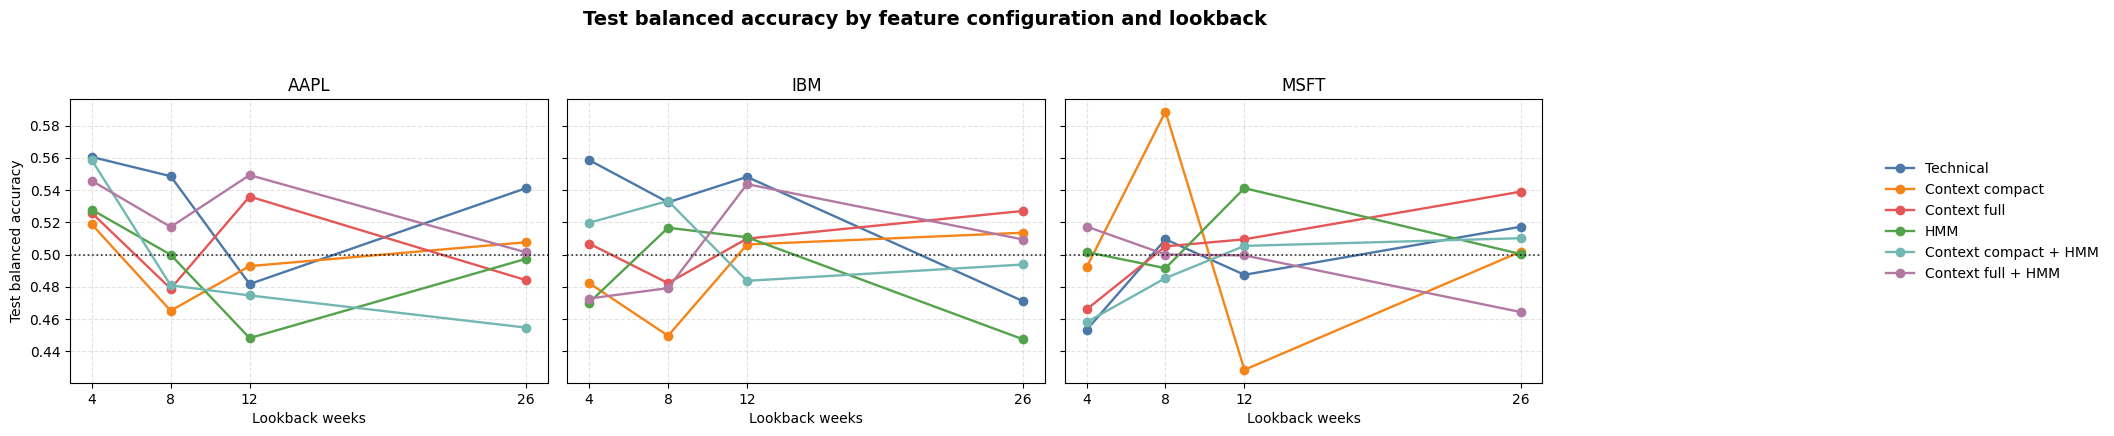

In [11]:
def plot_metric_by_config(metric_col: str, ylabel: str, title: str, filename: str, reference_line: float | None = None) -> None:
    fig, axes = plt.subplots(1, len(TICKERS), figsize=(6.2 * len(TICKERS), 4.4), sharey=True)
    if len(TICKERS) == 1:
        axes = [axes]
    for ax, ticker in zip(axes, TICKERS):
        df_t = weekly_context_lstm_results_df.loc[weekly_context_lstm_results_df["ticker"] == ticker]
        for config_name in FEATURE_CONFIG_ORDER:
            if config_name not in df_t["feature_config"].unique():
                continue
            df_tc = df_t.loc[df_t["feature_config"] == config_name].sort_values("lookback")
            ax.plot(
                df_tc["lookback"],
                df_tc[metric_col],
                marker="o",
                linewidth=1.7,
                label=FEATURE_CONFIG_LABELS[config_name],
                color=CONFIG_COLORS[config_name],
            )
        if reference_line is not None:
            ax.axhline(reference_line, color="black", linestyle=":", linewidth=1.2, alpha=0.8)
        ax.set_title(ticker)
        ax.set_xlabel("Lookback weeks")
        ax.set_xticks(LOOKBACK_GRID)
        ax.grid(True, linestyle="--", alpha=0.35)
    axes[0].set_ylabel(ylabel)
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
    fig.suptitle(title, fontsize=14, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 0.84, 0.94])
    save_plot(filename)
    plt.show()
    plt.close(fig)


plot_metric_by_config(
    "test_balanced_accuracy",
    "Test balanced accuracy",
    "Test balanced accuracy by feature configuration and lookback",
    "test_balanced_accuracy_by_config_ticker_lookback.png",
    reference_line=0.5,
)

## 11. Test ROC-AUC by feature config, ticker, and lookback

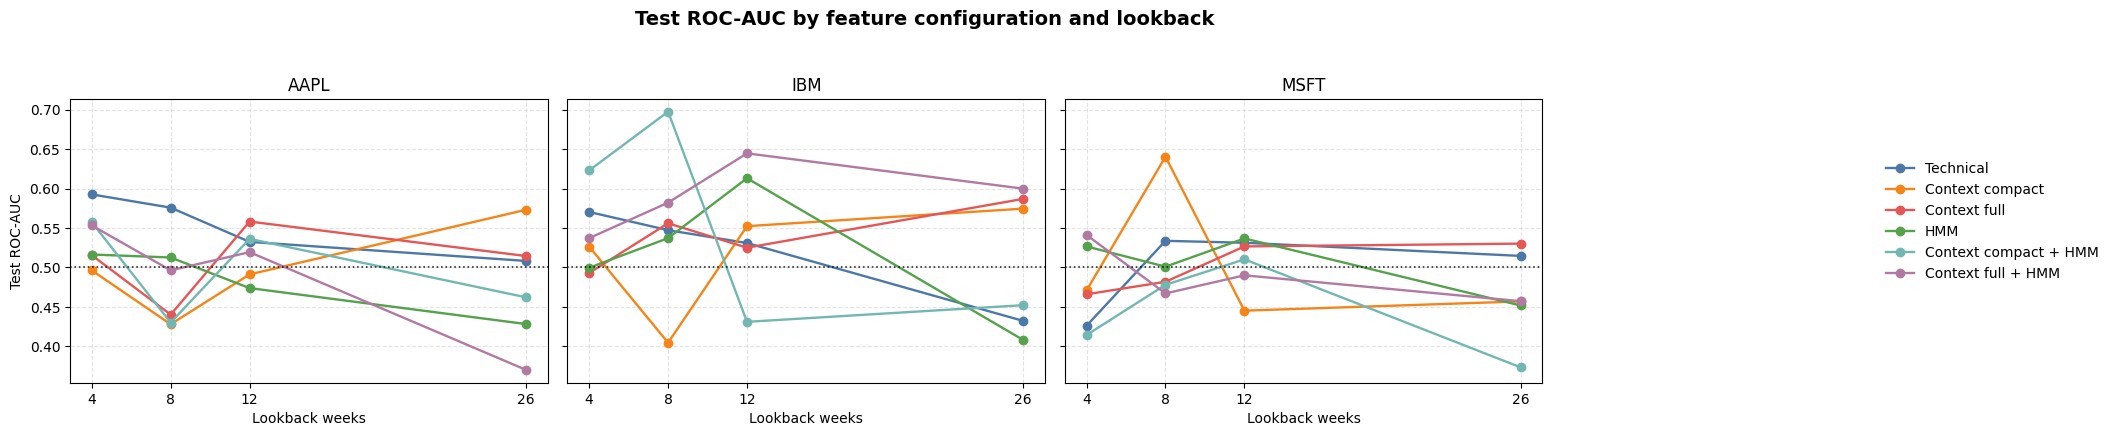

In [12]:
plot_metric_by_config(
    "test_roc_auc",
    "Test ROC-AUC",
    "Test ROC-AUC by feature configuration and lookback",
    "test_roc_auc_by_config_ticker_lookback.png",
    reference_line=0.5,
)

## 12. Same-lookback delta plots

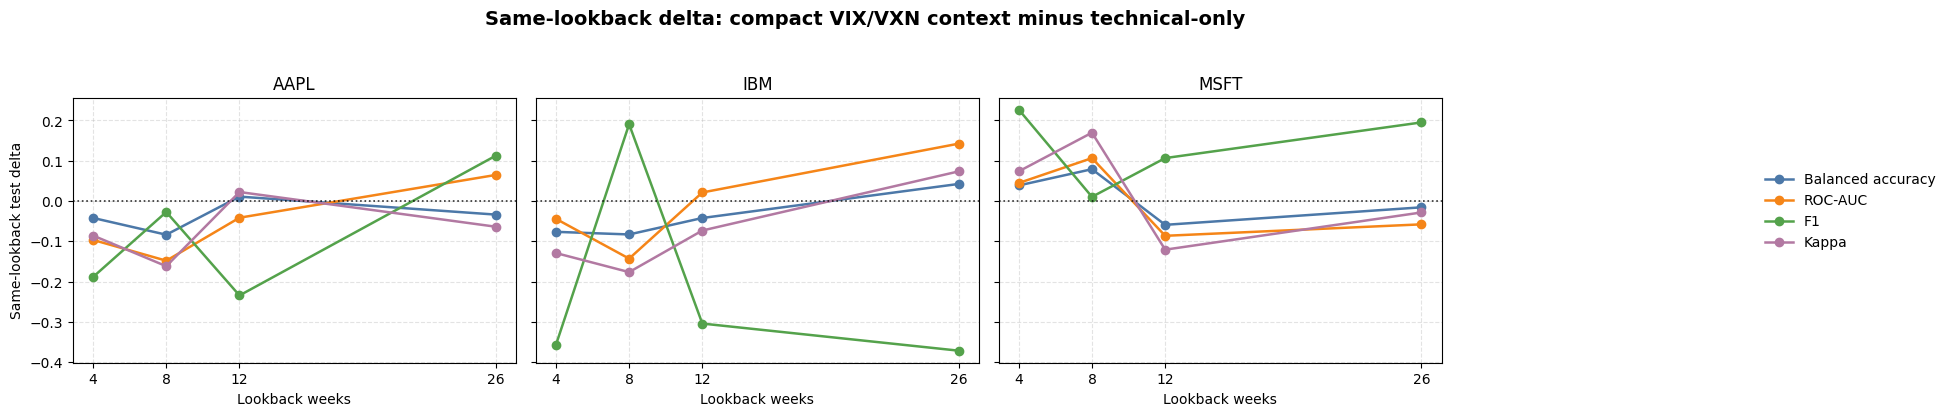

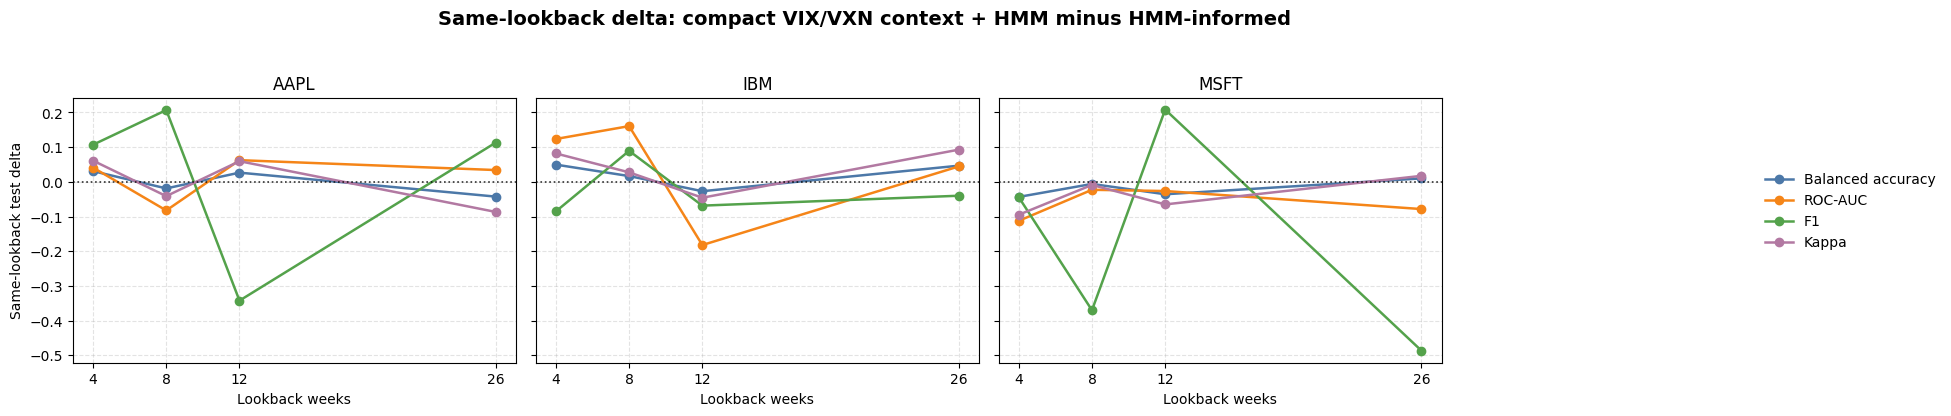

In [13]:
def plot_delta_comparison(comparison_label: str, title: str, filename: str) -> None:
    delta_df = weekly_context_lstm_same_lookback_deltas_df.loc[
        weekly_context_lstm_same_lookback_deltas_df["comparison"] == comparison_label
    ].copy()
    fig, axes = plt.subplots(1, len(TICKERS), figsize=(5.8 * len(TICKERS), 4.2), sharey=True)
    if len(TICKERS) == 1:
        axes = [axes]
    delta_metrics = [
        ("delta_test_balanced_accuracy", "Balanced accuracy"),
        ("delta_test_roc_auc", "ROC-AUC"),
        ("delta_test_f1", "F1"),
        ("delta_test_kappa", "Kappa"),
    ]
    colors = ["#4C78A8", "#F58518", "#54A24B", "#B279A2"]
    for ax, ticker in zip(axes, TICKERS):
        df_t = delta_df.loc[delta_df["ticker"] == ticker].sort_values("lookback")
        for (metric_col, label), color in zip(delta_metrics, colors):
            ax.plot(df_t["lookback"], df_t[metric_col], marker="o", linewidth=1.8, label=label, color=color)
        ax.axhline(0, color="black", linestyle=":", linewidth=1.2, alpha=0.8)
        ax.set_title(ticker)
        ax.set_xlabel("Lookback weeks")
        ax.set_xticks(LOOKBACK_GRID)
        ax.grid(True, linestyle="--", alpha=0.35)
    axes[0].set_ylabel("Same-lookback test delta")
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
    fig.suptitle(title, fontsize=14, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 0.84, 0.94])
    save_plot(filename)
    plt.show()
    plt.close(fig)


plot_delta_comparison(
    "context_compact_over_technical_only",
    "Same-lookback delta: compact VIX/VXN context minus technical-only",
    "delta_vol_context_compact_minus_technical_only.png",
)
plot_delta_comparison(
    "context_compact_hmm_over_hmm_informed",
    "Same-lookback delta: compact VIX/VXN context + HMM minus HMM-informed",
    "delta_vol_context_compact_hmm_minus_hmm_informed.png",
)

## 13. Selected-model comparison by ticker and feature configuration

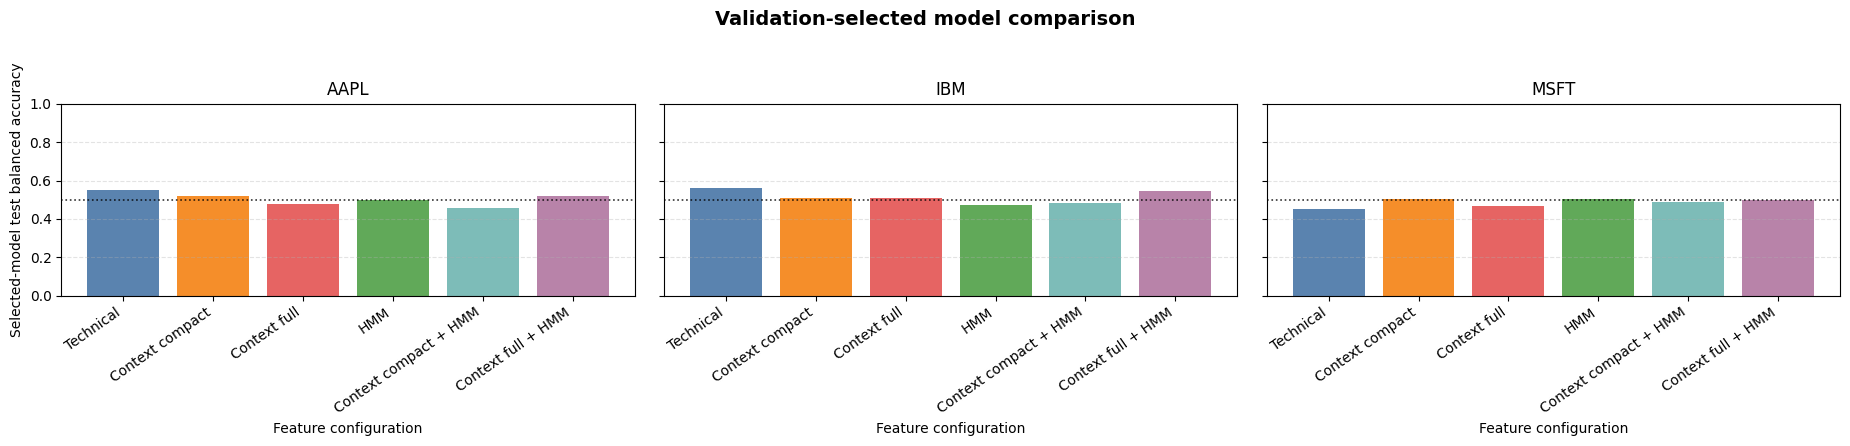

In [14]:
fig, axes = plt.subplots(1, len(TICKERS), figsize=(6.2 * len(TICKERS), 4.5), sharey=True)
if len(TICKERS) == 1:
    axes = [axes]

for ax, ticker in zip(axes, TICKERS):
    df_t = weekly_context_lstm_final_model_comparison_df.loc[weekly_context_lstm_final_model_comparison_df["ticker"] == ticker].copy()
    df_t["feature_config"] = pd.Categorical(df_t["feature_config"], categories=FEATURE_CONFIG_ORDER, ordered=True)
    df_t = df_t.sort_values("feature_config")
    labels = [FEATURE_CONFIG_LABELS[c] for c in df_t["feature_config"].astype(str)]
    colors = [CONFIG_COLORS[c] for c in df_t["feature_config"].astype(str)]
    ax.bar(np.arange(len(df_t)), df_t["test_balanced_accuracy"], color=colors, alpha=0.92)
    ax.axhline(0.5, color="black", linestyle=":", linewidth=1.2, alpha=0.8)
    ax.set_xticks(np.arange(len(df_t)))
    ax.set_xticklabels(labels, rotation=35, ha="right")
    ax.set_ylim(0, 1)
    ax.set_title(ticker)
    ax.set_xlabel("Feature configuration")
    ax.grid(True, axis="y", linestyle="--", alpha=0.35)
axes[0].set_ylabel("Selected-model test balanced accuracy")
fig.suptitle("Validation-selected model comparison", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.93])
save_plot("selected_model_comparison_by_ticker_feature_config.png")
plt.show()
plt.close(fig)

## 14. Selected-model confusion matrices

C:\Users\Admin\AppData\Local\Temp\ipykernel_9140\260451057.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.98, 0.94])


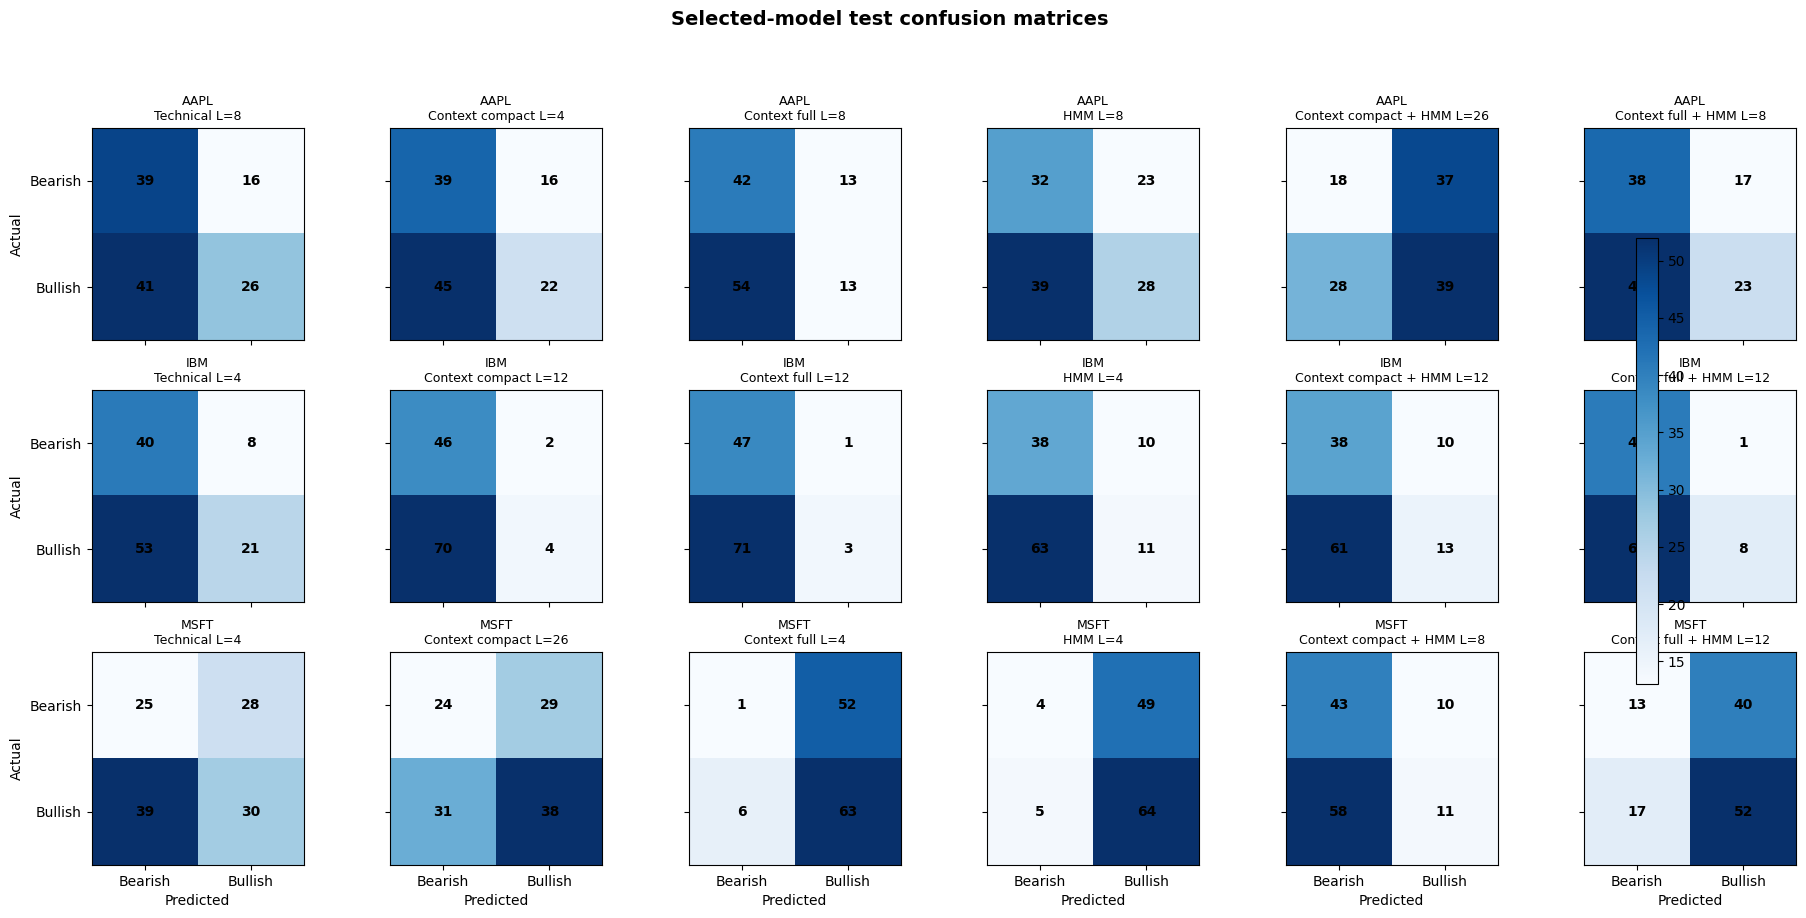

In [15]:
selected_test_df = selected_test_predictions()

n_rows = len(TICKERS)
n_cols = len(FEATURE_CONFIG_ORDER)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3.1 * n_rows), sharex=True, sharey=True)
if n_rows == 1:
    axes = np.asarray([axes])
if n_cols == 1:
    axes = axes.reshape(n_rows, 1)

last_image = None
for i, ticker in enumerate(TICKERS):
    for j, config_name in enumerate(FEATURE_CONFIG_ORDER):
        ax = axes[i, j]
        df_tc = selected_test_df.loc[(selected_test_df["Ticker"] == ticker) & (selected_test_df["feature_config"] == config_name)]
        if df_tc.empty:
            ax.set_visible(False)
            continue
        cm = confusion_matrix(df_tc["Target_State_Binary"], df_tc["predicted_state_binary"], labels=[0, 1])
        last_image = ax.imshow(cm, cmap="Blues")
        for row_idx in range(cm.shape[0]):
            for col_idx in range(cm.shape[1]):
                ax.text(col_idx, row_idx, str(cm[row_idx, col_idx]), ha="center", va="center", color="black", fontsize=10, fontweight="bold")
        selected_lookback = int(df_tc["lookback"].iloc[0])
        ax.set_title(f"{ticker}\n{FEATURE_CONFIG_LABELS[config_name]} L={selected_lookback}", fontsize=9)
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(["Bearish", "Bullish"])
        ax.set_yticklabels(["Bearish", "Bullish"])
        if i == n_rows - 1:
            ax.set_xlabel("Predicted")
        if j == 0:
            ax.set_ylabel("Actual")

if last_image is not None:
    fig.colorbar(last_image, ax=axes, fraction=0.015, pad=0.01)
fig.suptitle("Selected-model test confusion matrices", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 0.98, 0.94])
save_plot("selected_model_confusion_matrices.png")
plt.show()
plt.close(fig)

## 15. Selected-model ROC curves

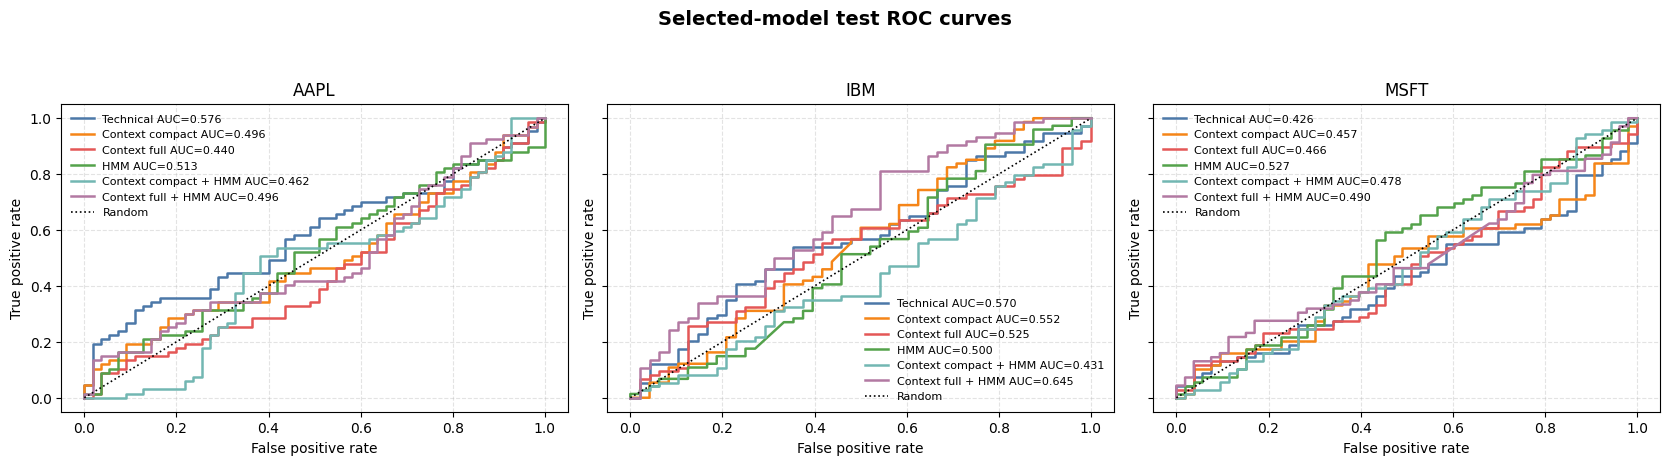

In [16]:
fig, axes = plt.subplots(1, len(TICKERS), figsize=(5.6 * len(TICKERS), 4.7), sharex=True, sharey=True)
if len(TICKERS) == 1:
    axes = [axes]

for ax, ticker in zip(axes, TICKERS):
    df_t = selected_test_df.loc[selected_test_df["Ticker"] == ticker]
    for config_name in FEATURE_CONFIG_ORDER:
        df_tc = df_t.loc[df_t["feature_config"] == config_name]
        if df_tc.empty or df_tc["Target_State_Binary"].nunique() < 2:
            continue
        fpr, tpr, _ = roc_curve(df_tc["Target_State_Binary"].astype(int), df_tc["predicted_bullish_probability"].astype(float))
        auc_value = roc_auc_score(df_tc["Target_State_Binary"].astype(int), df_tc["predicted_bullish_probability"].astype(float))
        ax.plot(fpr, tpr, linewidth=1.8, label=f"{FEATURE_CONFIG_LABELS[config_name]} AUC={auc_value:.3f}", color=CONFIG_COLORS[config_name])
    ax.plot([0, 1], [0, 1], color="black", linestyle=":", linewidth=1.2, label="Random")
    ax.set_title(ticker)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(fontsize=8, frameon=False)
fig.suptitle("Selected-model test ROC curves", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.93])
save_plot("selected_model_roc_curves.png")
plt.show()
plt.close(fig)

In [3]:
!pip install plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.9 MB 10.7 MB/s eta 0:00:01
   ------------ --------------------------- 3.1/9.9 MB 10.6 MB/s eta 0:00:01
   ---------------------- ----------------- 5.5/9.9 MB 11.1 MB/s eta 0:00:01
   ------------------------------- -------- 7.9/9.9 MB 11.1 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 11.2 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 10.0 MB/s  0:00:01


In [4]:

import plotly.graph_objects as go
from sklearn.metrics import roc_curve, roc_auc_score

# Use AAPL, IBM, MSFT separately
for ticker in ["AAPL", "IBM", "MSFT"]:
    df_t = selected_test_df.loc[selected_test_df["Ticker"] == ticker].copy()

    fig = go.Figure()

    for config_name in FEATURE_CONFIG_ORDER:
        df_tc = df_t.loc[df_t["feature_config"] == config_name].copy()

        if df_tc.empty or df_tc["Target_State_Binary"].nunique() < 2:
            continue

        y_true = df_tc["Target_State_Binary"].astype(int)
        y_prob = df_tc["predicted_bullish_probability"].astype(float)

        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc_value = roc_auc_score(y_true, y_prob)

        fig.add_trace(
            go.Scatter(
                x=fpr,
                y=tpr,
                mode="lines",
                name=f"{FEATURE_CONFIG_LABELS[config_name]} AUC={auc_value:.3f}",
                line=dict(
                    width=2,
                    color=CONFIG_COLORS.get(config_name, None)
                ),
                hovertemplate=(
                    "False positive rate=%{x:.3f}<br>"
                    "True positive rate=%{y:.3f}<extra></extra>"
                ),
            )
        )

    fig.add_trace(
        go.Scatter(
            x=[0, 1],
            y=[0, 1],
            mode="lines",
            name="Random",
            line=dict(color="black", width=1.5, dash="dot"),
        )
    )

    fig.update_layout(
        title=f"{ticker} selected-model test ROC curves",
        xaxis_title="False positive rate",
        yaxis_title="True positive rate",
        template="plotly_white",
        width=750,
        height=550,
        legend=dict(
            orientation="v",
            x=0.02,
            y=0.98,
            bgcolor="rgba(255,255,255,0.7)",
        ),
    )

    fig.update_xaxes(range=[0, 1], showgrid=True)
    fig.update_yaxes(range=[0, 1], showgrid=True)

    fig.show()

NameError: name 'selected_test_df' is not defined

## 16. Predicted probability distributions by true class

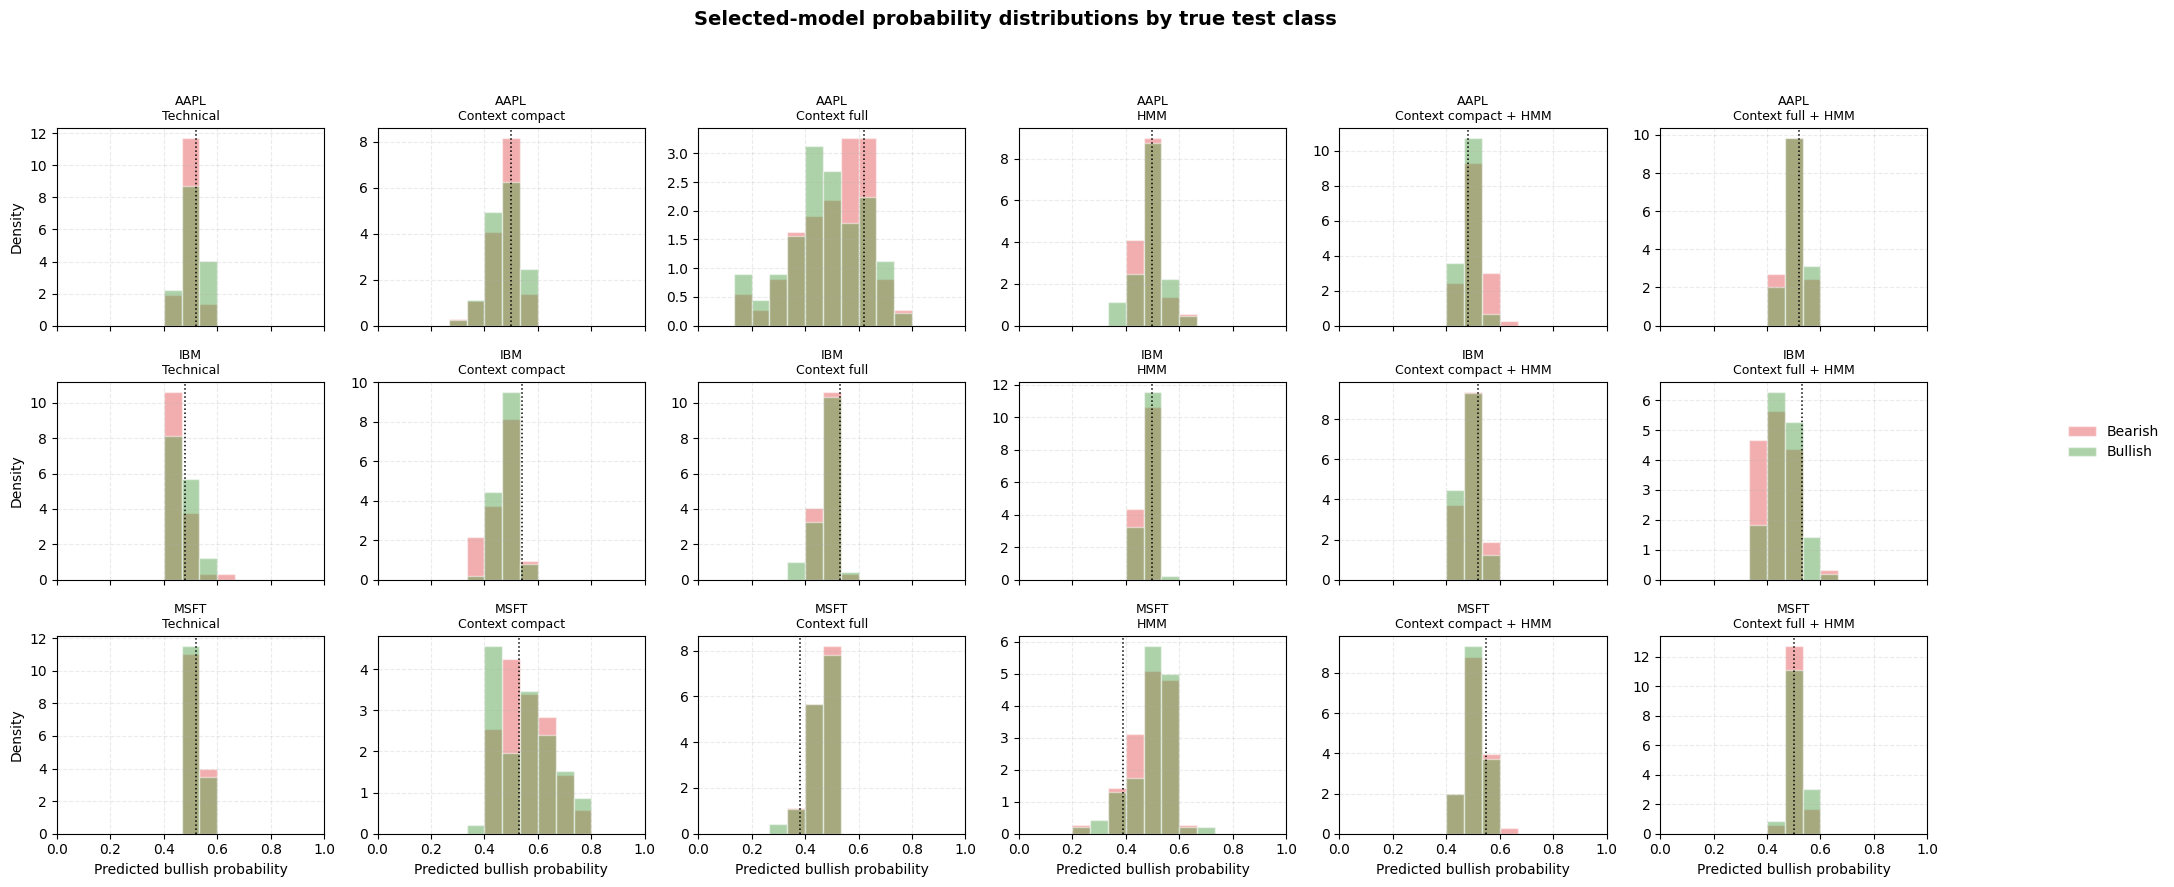

In [17]:
selected_test_df = selected_test_df.copy()
selected_test_df["actual_state"] = np.where(selected_test_df["Target_State_Binary"] == 1, "Bullish", "Bearish")

fig, axes = plt.subplots(len(TICKERS), len(FEATURE_CONFIG_ORDER), figsize=(3.4 * len(FEATURE_CONFIG_ORDER), 3.0 * len(TICKERS)), sharex=True, sharey=False)
if len(TICKERS) == 1:
    axes = np.asarray([axes])
if len(FEATURE_CONFIG_ORDER) == 1:
    axes = axes.reshape(len(TICKERS), 1)

bins = np.linspace(0, 1, 16)
for i, ticker in enumerate(TICKERS):
    for j, config_name in enumerate(FEATURE_CONFIG_ORDER):
        ax = axes[i, j]
        df_tc = selected_test_df.loc[(selected_test_df["Ticker"] == ticker) & (selected_test_df["feature_config"] == config_name)]
        if df_tc.empty:
            ax.set_visible(False)
            continue
        for state in ["Bearish", "Bullish"]:
            values = df_tc.loc[df_tc["actual_state"] == state, "predicted_bullish_probability"]
            ax.hist(values, bins=bins, alpha=0.48, density=True, label=state, color=STATE_COLORS[state], edgecolor="white")
        threshold = float(df_tc["decision_threshold"].iloc[0])
        ax.axvline(threshold, color="black", linestyle=":", linewidth=1.1)
        ax.set_xlim(0, 1)
        ax.set_title(f"{ticker}\n{FEATURE_CONFIG_LABELS[config_name]}", fontsize=9)
        ax.grid(True, linestyle="--", alpha=0.25)
        if i == len(TICKERS) - 1:
            ax.set_xlabel("Predicted bullish probability")
        if j == 0:
            ax.set_ylabel("Density")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
fig.suptitle("Selected-model probability distributions by true test class", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 0.96, 0.94])
save_plot("selected_model_probability_distributions_by_true_class.png")
plt.show()
plt.close(fig)

## 17. Training and validation AUC curves for selected models

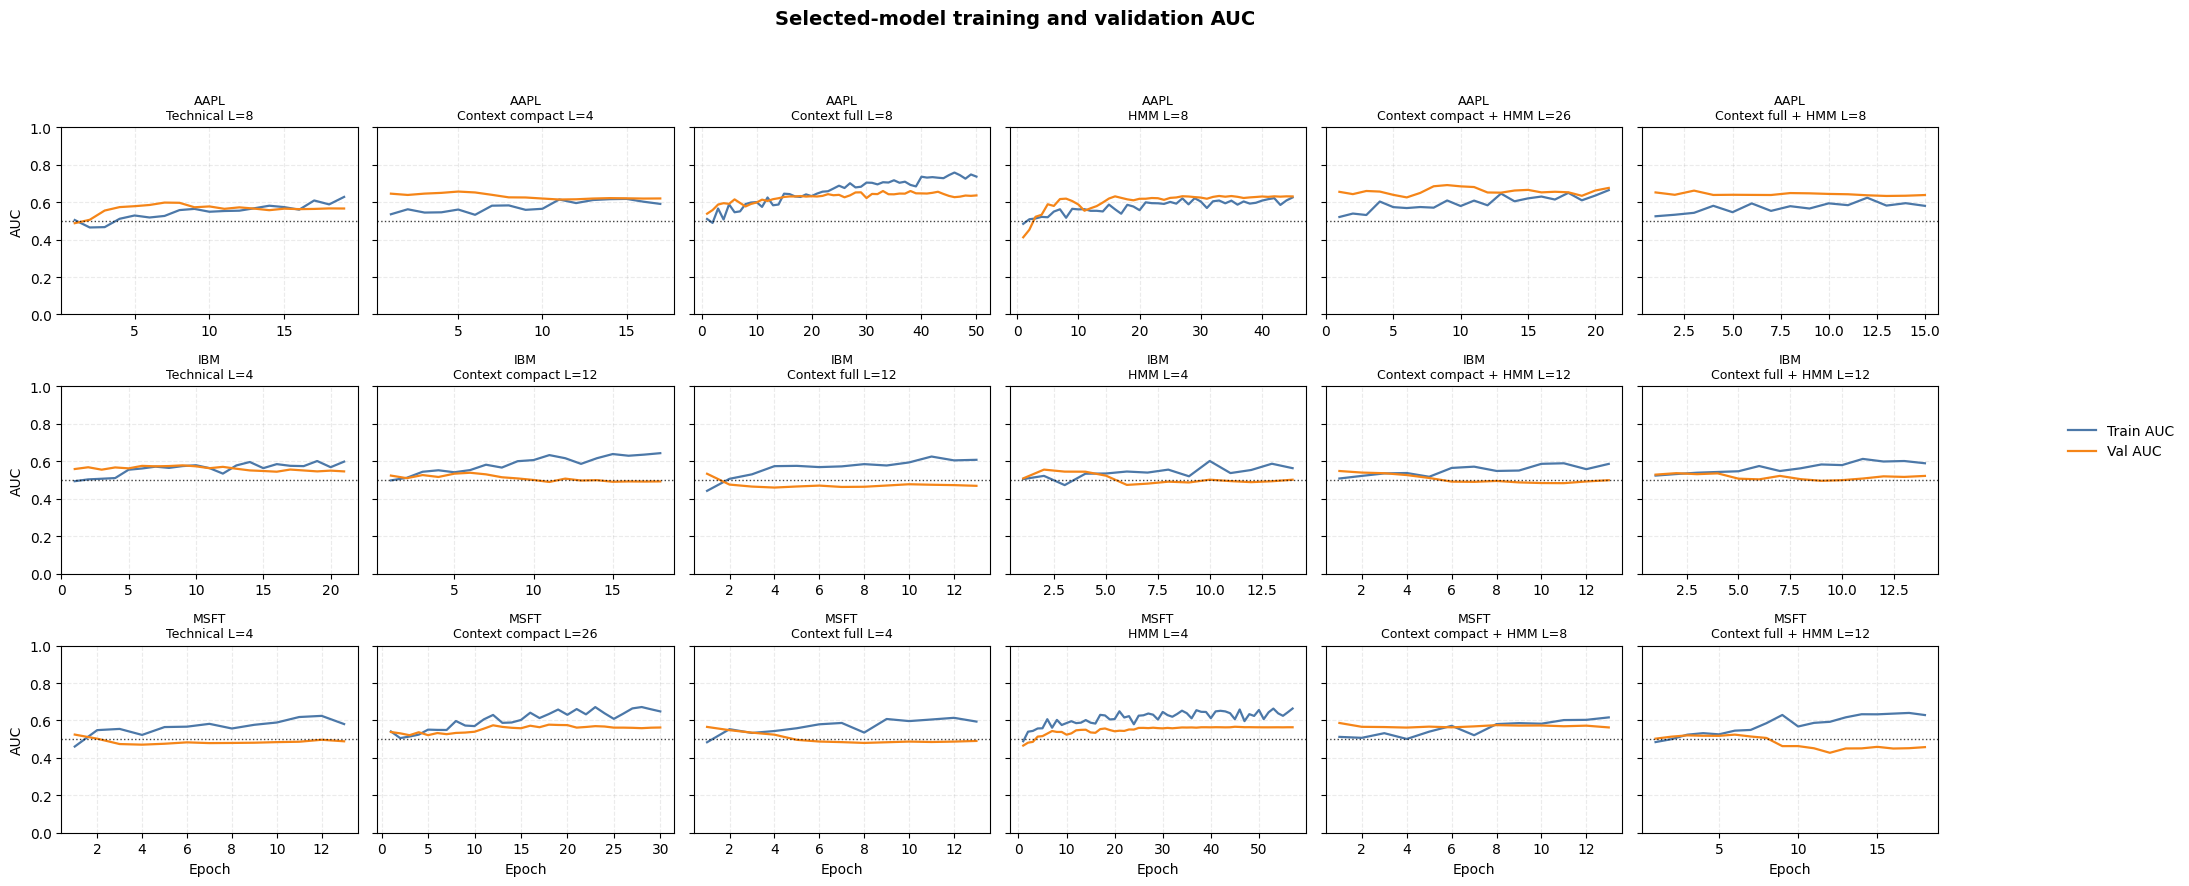

In [18]:
selected_history_df = selected_history()

fig, axes = plt.subplots(len(TICKERS), len(FEATURE_CONFIG_ORDER), figsize=(3.4 * len(FEATURE_CONFIG_ORDER), 3.0 * len(TICKERS)), sharex=False, sharey=True)
if len(TICKERS) == 1:
    axes = np.asarray([axes])
if len(FEATURE_CONFIG_ORDER) == 1:
    axes = axes.reshape(len(TICKERS), 1)

for i, ticker in enumerate(TICKERS):
    for j, config_name in enumerate(FEATURE_CONFIG_ORDER):
        ax = axes[i, j]
        df_tc = selected_history_df.loc[(selected_history_df["ticker"] == ticker) & (selected_history_df["feature_config"] == config_name)].sort_values("epoch")
        if df_tc.empty:
            ax.set_visible(False)
            continue
        lookback = int(df_tc["lookback"].iloc[0])
        ax.plot(df_tc["epoch"], df_tc["auc"], linewidth=1.6, label="Train AUC", color="#4C78A8")
        ax.plot(df_tc["epoch"], df_tc["val_auc"], linewidth=1.6, label="Val AUC", color="#F58518")
        ax.axhline(0.5, color="black", linestyle=":", linewidth=1.0, alpha=0.75)
        ax.set_ylim(0, 1)
        ax.set_title(f"{ticker}\n{FEATURE_CONFIG_LABELS[config_name]} L={lookback}", fontsize=9)
        ax.grid(True, linestyle="--", alpha=0.25)
        if i == len(TICKERS) - 1:
            ax.set_xlabel("Epoch")
        if j == 0:
            ax.set_ylabel("AUC")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
fig.suptitle("Selected-model training and validation AUC", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 0.96, 0.94])
save_plot("selected_model_training_validation_auc_curves.png")
plt.show()
plt.close(fig)

## 18. Training and validation loss curves for selected models

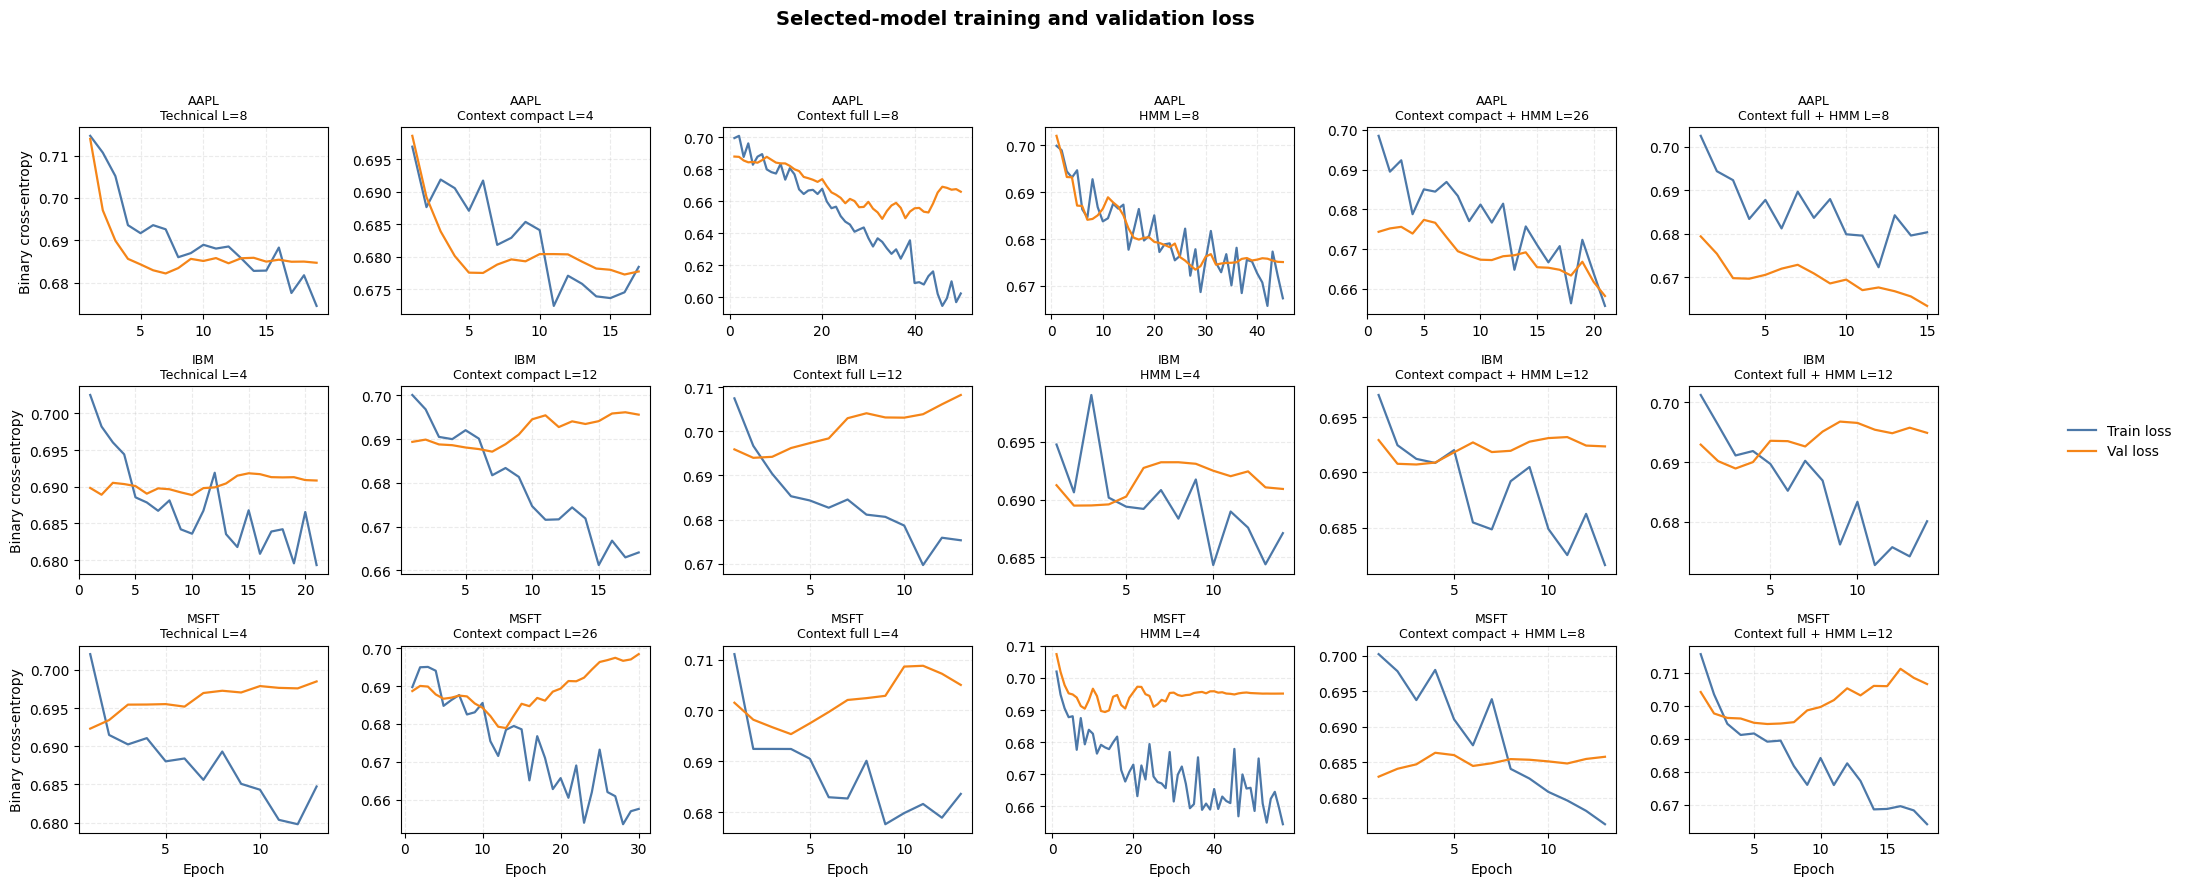

In [19]:
fig, axes = plt.subplots(len(TICKERS), len(FEATURE_CONFIG_ORDER), figsize=(3.4 * len(FEATURE_CONFIG_ORDER), 3.0 * len(TICKERS)), sharex=False, sharey=False)
if len(TICKERS) == 1:
    axes = np.asarray([axes])
if len(FEATURE_CONFIG_ORDER) == 1:
    axes = axes.reshape(len(TICKERS), 1)

for i, ticker in enumerate(TICKERS):
    for j, config_name in enumerate(FEATURE_CONFIG_ORDER):
        ax = axes[i, j]
        df_tc = selected_history_df.loc[(selected_history_df["ticker"] == ticker) & (selected_history_df["feature_config"] == config_name)].sort_values("epoch")
        if df_tc.empty:
            ax.set_visible(False)
            continue
        lookback = int(df_tc["lookback"].iloc[0])
        ax.plot(df_tc["epoch"], df_tc["loss"], linewidth=1.6, label="Train loss", color="#4C78A8")
        ax.plot(df_tc["epoch"], df_tc["val_loss"], linewidth=1.6, label="Val loss", color="#F58518")
        ax.set_title(f"{ticker}\n{FEATURE_CONFIG_LABELS[config_name]} L={lookback}", fontsize=9)
        ax.grid(True, linestyle="--", alpha=0.25)
        if i == len(TICKERS) - 1:
            ax.set_xlabel("Epoch")
        if j == 0:
            ax.set_ylabel("Binary cross-entropy")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
fig.suptitle("Selected-model training and validation loss", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 0.96, 0.94])
save_plot("selected_model_training_validation_loss_curves.png")
plt.show()
plt.close(fig)

## 19. Final interpretation

This notebook tests whether external volatility context improves weekly stock-direction prediction. VIX and VXN are not expected to perfectly separate next-week Bullish and Bearish weeks by themselves. Instead, they provide market-regime context that may interact with stock-specific technical features and HMM regime probabilities.

The key comparison is not a single accuracy number. The important question is whether the context-aware models improve same-lookback performance relative to technical-only and HMM-informed baselines. If VIX/VXN improve balanced accuracy or ROC-AUC consistently, this suggests that the previous weak performance was partly due to a missing market-context information set. If the improvement is inconsistent, then the conclusion should be cautious: external volatility context is theoretically meaningful but still does not fully solve the difficulty of next-week direction prediction.

## 20. Final sanity checks

In [20]:
required_output_files = [
    OUTPUT_DIR / "weekly_context_lstm_results.csv",
    OUTPUT_DIR / "weekly_context_lstm_predictions.csv",
    OUTPUT_DIR / "weekly_context_lstm_training_history.csv",
    OUTPUT_DIR / "weekly_context_lstm_selected_models.csv",
    OUTPUT_DIR / "weekly_context_lstm_same_lookback_deltas.csv",
    OUTPUT_DIR / "weekly_context_lstm_summary_by_config.csv",
    OUTPUT_DIR / "weekly_context_lstm_summary_by_ticker.csv",
    OUTPUT_DIR / "weekly_context_lstm_final_model_comparison.csv",
]

required_plot_files = [
    PLOTS_DIR / "test_balanced_accuracy_by_config_ticker_lookback.png",
    PLOTS_DIR / "test_roc_auc_by_config_ticker_lookback.png",
    PLOTS_DIR / "delta_vol_context_compact_minus_technical_only.png",
    PLOTS_DIR / "delta_vol_context_compact_hmm_minus_hmm_informed.png",
    PLOTS_DIR / "selected_model_comparison_by_ticker_feature_config.png",
    PLOTS_DIR / "selected_model_confusion_matrices.png",
    PLOTS_DIR / "selected_model_roc_curves.png",
    PLOTS_DIR / "selected_model_probability_distributions_by_true_class.png",
    PLOTS_DIR / "selected_model_training_validation_auc_curves.png",
    PLOTS_DIR / "selected_model_training_validation_loss_curves.png",
]

trained_configs = set(weekly_context_lstm_results_df["feature_config"])
expected_configs = set(FEATURE_CONFIGS)
actual_feature_counts = weekly_context_lstm_results_df.groupby("feature_config")["n_features"].nunique().to_dict()

sanity_checks = {
    "all feature configurations were trained": trained_configs == expected_configs,
    "all ticker-lookback-config runs were trained": len(weekly_context_lstm_results_df) == EXPECTED_TRAINING_RUNS,
    "feature counts match expectations": all(
        actual_feature_counts.get(config_name) == 1
        and int(weekly_context_lstm_results_df.loc[weekly_context_lstm_results_df["feature_config"] == config_name, "n_features"].iloc[0]) == EXPECTED_FEATURE_COUNTS[config_name]
        for config_name in FEATURE_CONFIGS
    ),
    "no leakage columns were used as features": not any(set(cols).intersection(LEAKAGE_COLUMNS) for cols in FEATURE_CONFIGS.values()),
    "HMM was not refitted": (not HMM_REFITTED_IN_THIS_NOTEBOOK) and ("hmmlearn" not in sys.modules),
    "no smoothed HMM probabilities are used": not any("smooth" in col.lower() for cols in FEATURE_CONFIGS.values() for col in cols),
    "only next-step HMM probabilities are used": all(col in HMM_FEATURES for cols in FEATURE_CONFIGS.values() for col in cols if col.startswith("HMM_")),
    "thresholds were selected only on validation data": "best_val_threshold_balanced_accuracy" in weekly_context_lstm_results_df.columns,
    "selected models were chosen only by validation metrics": weekly_context_lstm_selected_models_df["selection_rule"].eq("highest validation ROC-AUC, then validation balanced accuracy, then validation F1").all(),
    "same-lookback delta tables were saved": (OUTPUT_DIR / "weekly_context_lstm_same_lookback_deltas.csv").exists(),
    "all required output files exist": all(path.exists() for path in required_output_files),
    "all required plot files exist": all(path.exists() for path in required_plot_files),
}

sanity_df = pd.DataFrame([{"check": check, "passed": bool(passed)} for check, passed in sanity_checks.items()])
display(sanity_df)

if not sanity_df["passed"].all():
    failed = sanity_df.loc[~sanity_df["passed"], "check"].tolist()
    raise AssertionError(f"Final sanity checks failed: {failed}")

print("All final sanity checks passed.")
print(f"Required CSV files: {len(required_output_files)}")
print(f"Required plot files: {len(required_plot_files)}")

,check,passed
0,all feature configurations were trained,True
1,all ticker-lookback-config runs were trained,True
2,feature counts match expectations,True
3,no leakage columns were used as features,True
4,HMM was not refitted,True
5,no smoothed HMM probabilities are used,True
6,only next-step HMM probabilities are used,True
7,thresholds were selected only on validation data,True
8,selected models were chosen only by validation...,True
9,same-lookback delta tables were saved,True


All final sanity checks passed.
Required CSV files: 8
Required plot files: 10


In [ ]:
# Robust Plotly ROC curves from saved weekly-context CSV outputs only.
# This cell does not train models and does not save figures.
# It installs Plotly into the CURRENT notebook kernel if Plotly is missing.

from pathlib import Path
import importlib.util
import subprocess
import sys


def ensure_package(import_name: str, pip_name: str | None = None) -> None:
    if importlib.util.find_spec(import_name) is None:
        package = pip_name or import_name
        print(f"Installing {package} into this notebook kernel:")
        print(sys.executable)
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])


ensure_package("plotly")
ensure_package("nbformat")

import pandas as pd
import plotly.graph_objects as go
from IPython.display import HTML, display
from sklearn.metrics import roc_curve, roc_auc_score

RUN_NAME = "weekly_context_lstm"
TICKERS_TO_PLOT = ["AAPL", "IBM", "MSFT"]

# VS Code sometimes shows a blank output area for Plotly HTML.
# Use browser mode by default because it is the most reliable.
# Options: "browser", "vscode", or "inline_html".
DISPLAY_MODE = "browser"


def show_plotly_html(fig) -> None:
    if DISPLAY_MODE == "browser":
        fig.show(renderer="browser")
        return

    if DISPLAY_MODE == "vscode":
        fig.show(renderer="vscode")
        return

    display(
        HTML(
            fig.to_html(
                full_html=False,
                include_plotlyjs=True,
                default_width="900px",
                default_height="580px",
                config={"displaylogo": False, "responsive": True},
            )
        )
    )


def find_project_root(run_name: str) -> Path:
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "outputs" / run_name).exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find outputs/{run_name}. Current working directory is: {Path.cwd()}"
    )


PROJECT_ROOT = find_project_root(RUN_NAME)
OUTPUT_DIR = PROJECT_ROOT / "outputs" / RUN_NAME

predictions_path = OUTPUT_DIR / f"{RUN_NAME}_predictions.csv"
selected_models_path = OUTPUT_DIR / f"{RUN_NAME}_selected_models.csv"

predictions_df = pd.read_csv(predictions_path)
selected_models_df = pd.read_csv(selected_models_path).rename(columns={"ticker": "Ticker"})

print("Python executable:", sys.executable)
print(f"Loaded predictions: {predictions_path}")
print(f"Loaded selected models: {selected_models_path}")
print("Predictions shape:", predictions_df.shape)
print("Selected models shape:", selected_models_df.shape)

required_prediction_cols = {
    "Ticker",
    "Split",
    "Target_State_Binary",
    "feature_config",
    "lookback",
    "predicted_bullish_probability",
}
missing_prediction_cols = sorted(required_prediction_cols - set(predictions_df.columns))
if missing_prediction_cols:
    raise KeyError(f"Missing prediction columns: {missing_prediction_cols}")

required_selected_cols = {"Ticker", "feature_config", "lookback"}
missing_selected_cols = sorted(required_selected_cols - set(selected_models_df.columns))
if missing_selected_cols:
    raise KeyError(f"Missing selected-model columns: {missing_selected_cols}")

test_predictions = predictions_df[
    predictions_df["Split"].astype(str).str.lower().eq("test")
].copy()

merge_keys = ["Ticker", "feature_config", "lookback"]
selected_keys = selected_models_df[merge_keys].drop_duplicates()
selected_test_df = test_predictions.merge(selected_keys, on=merge_keys, how="inner")

print("Selected test predictions shape:", selected_test_df.shape)
print("Rows by ticker:", selected_test_df.groupby("Ticker").size().to_dict())
if selected_test_df.empty:
    raise ValueError("No selected test predictions found after merging saved CSV outputs.")

label_map = {
    "technical_only": "Technical",
    "hmm_informed": "HMM",
    "vol_context_compact": "Vol compact",
    "vol_context_compact_hmm": "Vol compact + HMM",
    "vol_context_full": "Vol full",
    "vol_context_full_hmm": "Vol full + HMM",
}

preferred_order = list(label_map)
present_configs = selected_test_df["feature_config"].dropna().astype(str).unique().tolist()
config_order = [c for c in preferred_order if c in present_configs]
config_order += sorted(c for c in present_configs if c not in config_order)

colors = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
]
color_map = {config: colors[i % len(colors)] for i, config in enumerate(config_order)}

for ticker in TICKERS_TO_PLOT:
    df_t = selected_test_df[selected_test_df["Ticker"].eq(ticker)].copy()

    if df_t.empty:
        print(f"Skipping {ticker}: no selected test rows found.")
        continue

    fig = go.Figure()
    traces_added = 0

    for config_name in config_order:
        df_tc = df_t[df_t["feature_config"].eq(config_name)].copy()
        if df_tc.empty:
            continue

        if df_tc["Target_State_Binary"].nunique() < 2:
            print(f"Skipping {ticker} / {config_name}: test target has fewer than two classes.")
            continue

        y_true = df_tc["Target_State_Binary"].astype(int)
        y_prob = df_tc["predicted_bullish_probability"].astype(float)

        fpr, tpr, _ = roc_curve(y_true, y_prob)
        auc_value = roc_auc_score(y_true, y_prob)

        lookback = int(df_tc["lookback"].iloc[0])
        label = label_map.get(config_name, config_name)

        fig.add_trace(
            go.Scatter(
                x=fpr,
                y=tpr,
                mode="lines",
                name=f"{label}, L={lookback}, AUC={auc_value:.3f}",
                line=dict(width=2.2, color=color_map[config_name]),
                hovertemplate=(
                    "False positive rate=%{x:.3f}<br>"
                    "True positive rate=%{y:.3f}<extra></extra>"
                ),
            )
        )
        traces_added += 1

    fig.add_trace(
        go.Scatter(
            x=[0, 1],
            y=[0, 1],
            mode="lines",
            name="Random",
            line=dict(color="black", width=1.5, dash="dot"),
        )
    )

    fig.update_layout(
        title=f"{ticker} selected-model test ROC curves: {RUN_NAME}",
        xaxis_title="False positive rate",
        yaxis_title="True positive rate",
        template="plotly_white",
        width=900,
        height=580,
        legend=dict(bgcolor="rgba(255,255,255,0.78)"),
        margin=dict(l=60, r=30, t=70, b=55),
    )
    fig.update_xaxes(range=[0, 1], showgrid=True)
    fig.update_yaxes(range=[0, 1], showgrid=True)

    print(f"Showing {ticker}: {traces_added} ROC traces")
    show_plotly_html(fig)


In [ ]:
# Robust Plotly result-summary plots from the saved weekly-context results CSV only.
# This cell does not train models and does not save figures.
# It installs Plotly into the CURRENT notebook kernel if Plotly is missing.

from pathlib import Path
import importlib.util
import subprocess
import sys


def ensure_package(import_name: str, pip_name: str | None = None) -> None:
    if importlib.util.find_spec(import_name) is None:
        package = pip_name or import_name
        print(f"Installing {package} into this notebook kernel:")
        print(sys.executable)
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])


ensure_package("plotly")
ensure_package("nbformat")

import pandas as pd
import plotly.express as px
from IPython.display import HTML, display

RUN_NAME = "weekly_context_lstm"
TICKERS_TO_PLOT = ["AAPL", "IBM", "MSFT"]

# VS Code sometimes shows a blank output area for Plotly HTML.
# Use browser mode by default because it is the most reliable.
# Options: "browser", "vscode", or "inline_html".
DISPLAY_MODE = "browser"


def show_plotly_html(fig) -> None:
    if DISPLAY_MODE == "browser":
        fig.show(renderer="browser")
        return

    if DISPLAY_MODE == "vscode":
        fig.show(renderer="vscode")
        return

    display(
        HTML(
            fig.to_html(
                full_html=False,
                include_plotlyjs=True,
                default_width="900px",
                default_height="580px",
                config={"displaylogo": False, "responsive": True},
            )
        )
    )


def find_project_root(run_name: str) -> Path:
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "outputs" / run_name).exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find outputs/{run_name}. Current working directory is: {Path.cwd()}"
    )


PROJECT_ROOT = find_project_root(RUN_NAME)
OUTPUT_DIR = PROJECT_ROOT / "outputs" / RUN_NAME
results_path = OUTPUT_DIR / f"{RUN_NAME}_results.csv"
results_df = pd.read_csv(results_path).rename(columns={"ticker": "Ticker"})

print("Python executable:", sys.executable)
print(f"Loaded results: {results_path}")
print("Results shape:", results_df.shape)

metric_candidates = ["test_roc_auc"]
metric_col = next((col for col in metric_candidates if col in results_df.columns), None)
if metric_col is None:
    raise KeyError(f"None of these ROC-AUC metric columns exist: {metric_candidates}")

label_map = {
    "technical_only": "Technical",
    "hmm_informed": "HMM",
    "vol_context_compact": "Vol compact",
    "vol_context_compact_hmm": "Vol compact + HMM",
    "vol_context_full": "Vol full",
    "vol_context_full_hmm": "Vol full + HMM",
}

plot_df = results_df.copy()
plot_df["feature_label"] = plot_df["feature_config"].map(label_map).fillna(plot_df["feature_config"])
plot_df["lookback"] = plot_df["lookback"].astype(int)

for ticker in TICKERS_TO_PLOT:
    df_t = plot_df[plot_df["Ticker"].eq(ticker)].copy()
    if df_t.empty:
        print(f"Skipping {ticker}: no result rows found.")
        continue

    fig = px.line(
        df_t.sort_values(["feature_label", "lookback"]),
        x="lookback",
        y=metric_col,
        color="feature_label",
        markers=True,
        title=f"{ticker} test ROC-AUC by lookback: {RUN_NAME}",
        labels={
            "lookback": "Lookback window",
            metric_col: "Test ROC-AUC",
            "feature_label": "Feature configuration",
        },
        template="plotly_white",
    )

    fig.add_hline(y=0.5, line_dash="dot", line_color="black", annotation_text="Random")
    fig.update_layout(
        width=900,
        height=580,
        legend=dict(bgcolor="rgba(255,255,255,0.78)"),
        margin=dict(l=60, r=30, t=70, b=55),
    )
    print(f"Showing {ticker}: result-summary ROC-AUC lines")
    show_plotly_html(fig)
